# EDA — TDAH en Niños: Análisis Bivariado

| | |
|---|---|
| **Variable objetivo** | `etiqueta` (13 categorías diagnósticas) |
| **Agrupación de trabajo** | 4 tipos principales para visualizaciones comparativas |
| **Tests estadísticos** | Kruskal-Wallis + Dunn (p-valor crudo) para numéricas; Chi-cuadrado para categóricas |

El análisis se organiza en seis bloques:

1. **Índices TDAH** vs etiqueta — el corazón del análisis
2. **Escalas BASC-3** vs etiqueta — comportamiento y atención por grupo
3. **CIT y fluidez fonológica** vs etiqueta — cognición por grupo
4. **Variables demográficas** vs etiqueta — edad, sexo, lateralidad, escolaridad
5. **Antecedentes clínicos** vs etiqueta — tablas de contingencia
6. **Perfil clínico global** — heatmap z-scores · radar chart · coordenadas paralelas

---

### Cómo leer este notebook

Cada bloque tiene tres secciones: **(1) la gráfica**, **(2) el test estadístico**, **(3) la interpretación**. Las secciones de interpretación aparecen en cajas azules con el encabezado 📋 **Interpretación**.

> **Nota sobre los tests estadísticos:** dado que ninguna variable sigue distribución normal (ver EDA univariado), se usan pruebas no paramétricas en todos los casos. Estas no asumen una forma particular de distribución y son más robustas para muestras clínicas heterogéneas.

---

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.facecolor': 'white',
})

C_BLUE = "#4C72B0"
C_ORG  = "#DD8452"
C_GRN  = "#55A868"
C_RED  = "#C44E52"
C_GRAY = "#8C8C8C"
PAL4   = sns.color_palette("Set2", 4)
PAL13  = sns.color_palette("tab20", 13)


In [2]:
df = pd.read_csv('../data/processed/processed_data.csv', encoding='utf-8-sig')

def tipo_principal(etiqueta):
    e = etiqueta.lower()
    if 'típico'      in e: return 'Desarrollo típico'
    if 'inatento'    in e: return 'TDAH inatento'
    if 'hiperactivo' in e: return 'TDAH hiper./impulsivo'
    if 'combinado'   in e: return 'TDAH combinado'
    return 'Otro'

df['tipo_tdah'] = df['etiqueta'].apply(tipo_principal)
ORDEN4 = ['Desarrollo típico', 'TDAH inatento', 'TDAH hiper./impulsivo', 'TDAH combinado']

print("Distribución por tipo principal:")
print(df['tipo_tdah'].value_counts().reindex(ORDEN4))


Distribución por tipo principal:
tipo_tdah
Desarrollo típico        112
TDAH inatento            301
TDAH hiper./impulsivo    175
TDAH combinado           287
Name: count, dtype: int64


In [3]:
def test_kw(df, variables, grupo_col='tipo_tdah'):
    filas = []
    for col in variables:
        grupos = [g[col].values for _, g in df.groupby(grupo_col)]
        H, p = stats.kruskal(*grupos)
        filas.append({'Variable': col, 'H (KW)': round(H, 3),
                      'p-valor': f'{p:.4e}', 'Significativo (α=0.05)': 'Sí' if p < 0.05 else 'No'})
    return pd.DataFrame(filas).set_index('Variable')

def dunn_heatmap(df, col, grupo_col='tipo_tdah', orden=None, ax=None, title=''):
    dunn = sp.posthoc_dunn(df, val_col=col, group_col=grupo_col, p_adjust=None)
    if orden:
        dunn = dunn.reindex(index=orden, columns=orden)
    mask = np.triu(np.ones_like(dunn, dtype=bool))
    annot = dunn.map(lambda v: f'{v:.3f}')
    sns.heatmap(dunn, annot=annot, fmt='', cmap='RdYlGn', vmin=0, vmax=0.1,
                mask=mask, ax=ax, linewidths=0.5, cbar_kws={'label': 'p-valor'})
    if ax:
        ax.set_title(title, fontsize=11)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)

def violin_strip(df, col, grupo_col='tipo_tdah', orden=None, ax=None,
                 palette=PAL4, ylabel='', hline=None, hline_label=''):
    sns.violinplot(data=df, x=grupo_col, y=col, order=orden,
                   palette=palette, inner='box', cut=0, ax=ax, linewidth=1.2)
    if hline is not None:
        ax.axhline(hline, color=C_RED, linestyle='--', linewidth=1.5,
                   label=hline_label, zorder=5)
        ax.legend(fontsize=8)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)


---
## Bloque 1 — Índices TDAH vs etiqueta diagnóstica

Los tres índices cuantifican la presencia de síntomas:
- **`indice_inatencion`**: proporción de síntomas de inatención observados (0 = ninguno, 1 = todos los ítems)
- **`indice_impuls_hiperac`**: proporción de síntomas de hiperactividad/impulsividad observados
- **`indice_tdah`**: promedio de los dos anteriores — índice general de severidad

Son las variables más directamente ligadas al diagnóstico, ya que forman parte del criterio de clasificación.

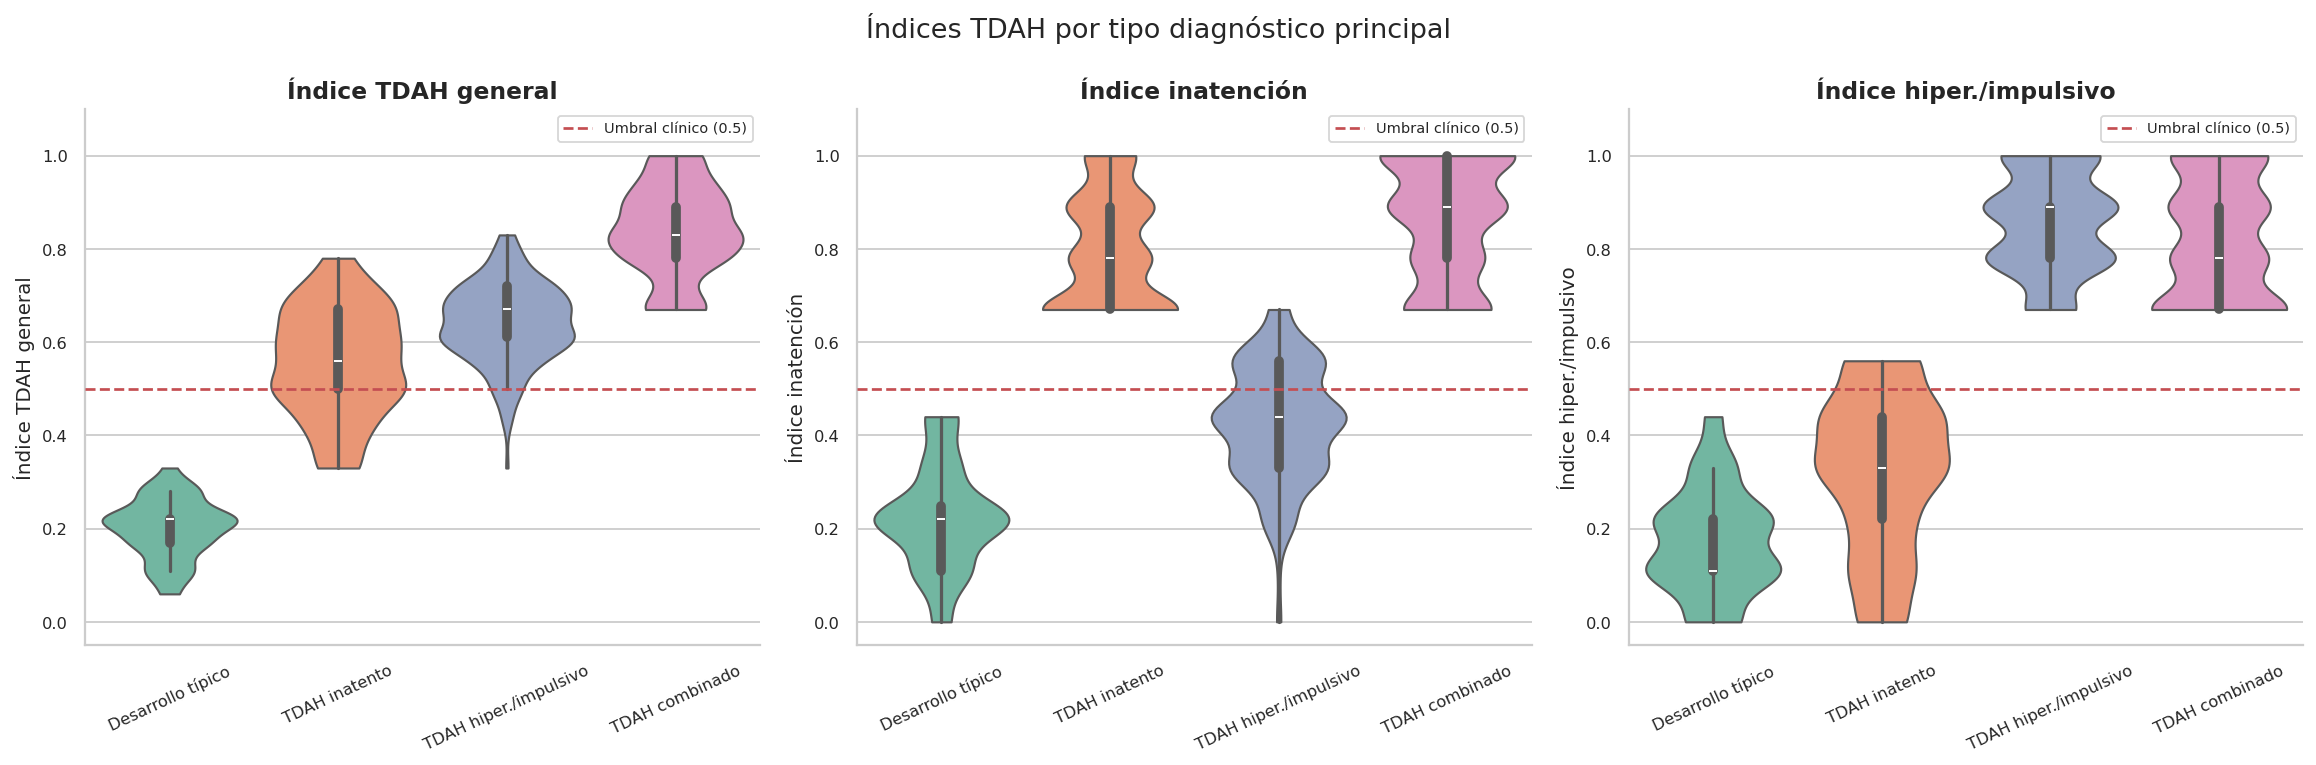

In [4]:
vars_indices = ['indice_tdah', 'indice_inatencion', 'indice_impuls_hiperac']
labels_idx   = ['Índice TDAH general', 'Índice inatención', 'Índice hiper./impulsivo']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Índices TDAH por tipo diagnóstico principal", fontsize=15)

for ax, col, label in zip(axes, vars_indices, labels_idx):
    violin_strip(df, col, orden=ORDEN4, ax=ax, ylabel=label,
                 hline=0.5, hline_label='Umbral clínico (0.5)')
    ax.set_title(label)
    ax.set_ylim(-0.05, 1.10)

plt.tight_layout()
plt.show()


📋 **Interpretación — Violinplots de índices TDAH**

**Cómo leer el gráfico:** cada violín muestra la distribución completa de valores para ese grupo. La caja interior representa el rango intercuartílico (Q1–Q3) y el punto central la mediana. Cuanto más ancho el violín en una zona, más casos tienen ese valor.

**La línea roja punteada (umbral 0.5)** equivale a que el niño presentó 6 o más de los 9 síntomas del criterio DSM-5 para esa dimensión. Es el umbral mínimo para que una dimensión contribuya al diagnóstico.

**Qué esperamos ver y por qué:**
- *TDAH inatento*: violín alto en `indice_inatencion` (cerca de 1.0) y bajo en `indice_impuls_hiperac`. Si un niño está diagnosticado como inatento, por definición tiene muchos síntomas de inatención y pocos de hiperactividad.
- *TDAH hiper./impulsivo*: patrón inverso — alto en `indice_impuls_hiperac`, bajo o moderado en `indice_inatencion`.
- *TDAH combinado*: ambos índices elevados simultáneamente — es el subtipo más severo.
- *Desarrollo típico*: ambos índices bajos, por debajo del umbral 0.5.

Si los violines muestran este patrón, confirma que el proceso de clasificación diagnóstica es internamente consistente con los datos clínicos.

In [5]:
kw_idx = test_kw(df, vars_indices)
print("Kruskal-Wallis — Índices TDAH")
display(kw_idx)


Kruskal-Wallis — Índices TDAH


,H (KW),p-valor,Significativo (α=0.05)
Variable,,,
indice_tdah,652.834,3.5388e-141,Sí
indice_inatencion,611.768,2.8332e-132,Sí
indice_impuls_hiperac,678.128,1.1602e-146,Sí


📋 **Interpretación — Test de Kruskal-Wallis (índices TDAH)**

**Qué mide:** el test de Kruskal-Wallis evalúa si las distribuciones de una variable numérica son iguales en todos los grupos. Es la versión no paramétrica del ANOVA — no requiere normalidad.

- **H (estadístico):** cuanto mayor, mayor es la diferencia entre grupos en relación con la variabilidad interna. Valores de H > 20 ya son indicativos de diferencias sustanciales.
- **p-valor:** probabilidad de observar estas diferencias por azar si los grupos fueran iguales. Con p < 0.05 rechazamos la hipótesis de igualdad.

**Lo que esperamos:** los tres índices deberían tener p-valores muy bajos y H elevados, dado que son el fundamento matemático del diagnóstico. Un H grande aquí no es sorprendente — *confirma* que los datos son consistentes con las etiquetas asignadas. El test de Dunn (abajo) nos dirá *cuáles pares de grupos* difieren.

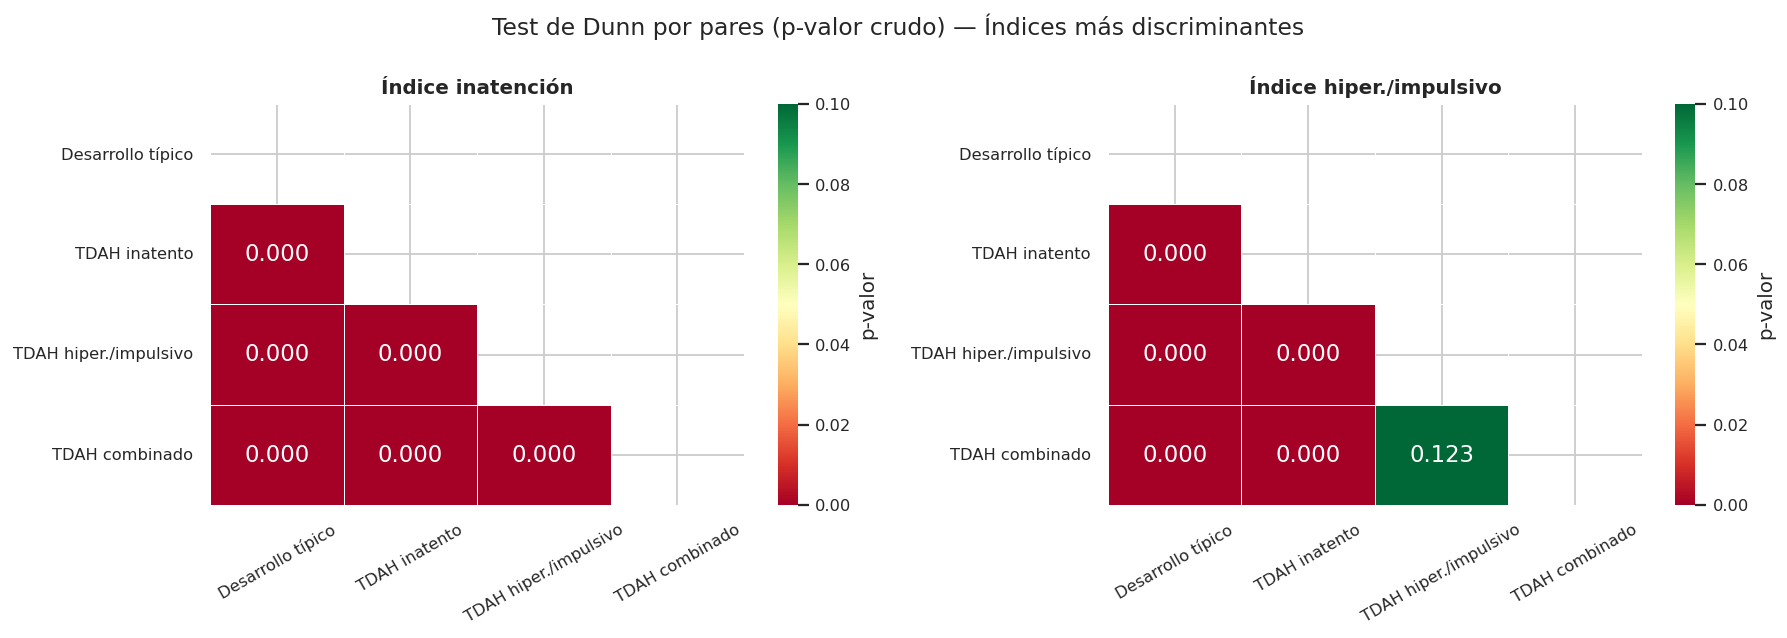

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test de Dunn por pares (p-valor crudo) — Índices más discriminantes", fontsize=13)

dunn_heatmap(df, 'indice_inatencion',     orden=ORDEN4, ax=axes[0], title='Índice inatención')
dunn_heatmap(df, 'indice_impuls_hiperac', orden=ORDEN4, ax=axes[1], title='Índice hiper./impulsivo')

plt.tight_layout()
plt.show()


📋 **Interpretación — Heatmaps de Dunn (comparaciones por pares)**

**Cómo leer el heatmap:** cada celda muestra el p-valor de la comparación entre el grupo de la fila y el de la columna. La escala de color va de verde (p alto → sin diferencia significativa) a rojo (p bajo → diferencia significativa).

- **Verde (p > 0.05):** los dos grupos no difieren estadísticamente en esa variable. Sus distribuciones son compatibles con ser iguales.
- **Rojo o amarillo (p ≤ 0.05):** existe una diferencia estadísticamente significativa entre esos dos grupos. El corte es 0.05, pero valores < 0.01 son más robustos.

**Qué buscar en `indice_inatencion`:** la comparación entre *Desarrollo típico* e *TDAH inatento* debería ser roja (máxima diferencia). La comparación entre *TDAH inatento* y *TDAH hiper./impulsivo* también, porque son subtipos opuestos en esa dimensión.

**Qué buscar en `indice_impuls_hiperac`:** el patrón inverso — *TDAH hiper./impulsivo* muy diferente de *Desarrollo típico* e *inatento*, pero similar a *TDAH combinado* (que también tiene hiperactividad elevada).

> **Nota:** el test de Dunn es un post-hoc que se aplica *después* de un Kruskal-Wallis significativo para identificar qué pares específicos difieren. Los p-valores aquí son crudos (sin corrección por múltiples comparaciones), lo que los hace algo más liberales.

---
## Bloque 2 — Escalas BASC-3 vs etiqueta diagnóstica

El **BASC-3** (Behavior Assessment System for Children, 3rd Edition) es un sistema de evaluación estandarizado del comportamiento y la adaptación. Las cinco escalas de este dataset están expresadas como **puntajes T**, una escala estandarizada en la población general:

| Puntaje T | Clasificación | Significado clínico |
|-----------|---------------|---------------------|
| < 60 | Promedio / Normal | Sin indicación clínica |
| 60 – 69 | Zona de Riesgo (*At-Risk*) | Requiere monitoreo, posible intervención |
| ≥ 70 | Clínicamente significativo | Nivel de dificultad que requiere atención clínica |

**Las escalas:**
- **Agresividad:** comportamientos agresivos hacia personas u objetos
- **Hiperactividad:** nivel de actividad excesiva e impulsividad conductual
- **Problemas de conducta:** comportamientos negativistas, desobedientes o disruptivos
- **Problemas de atención:** dificultades para mantener la atención y concentrarse en tareas
- **Atipicidad:** comportamientos inusuales, extraños o fuera de lo esperado para la edad

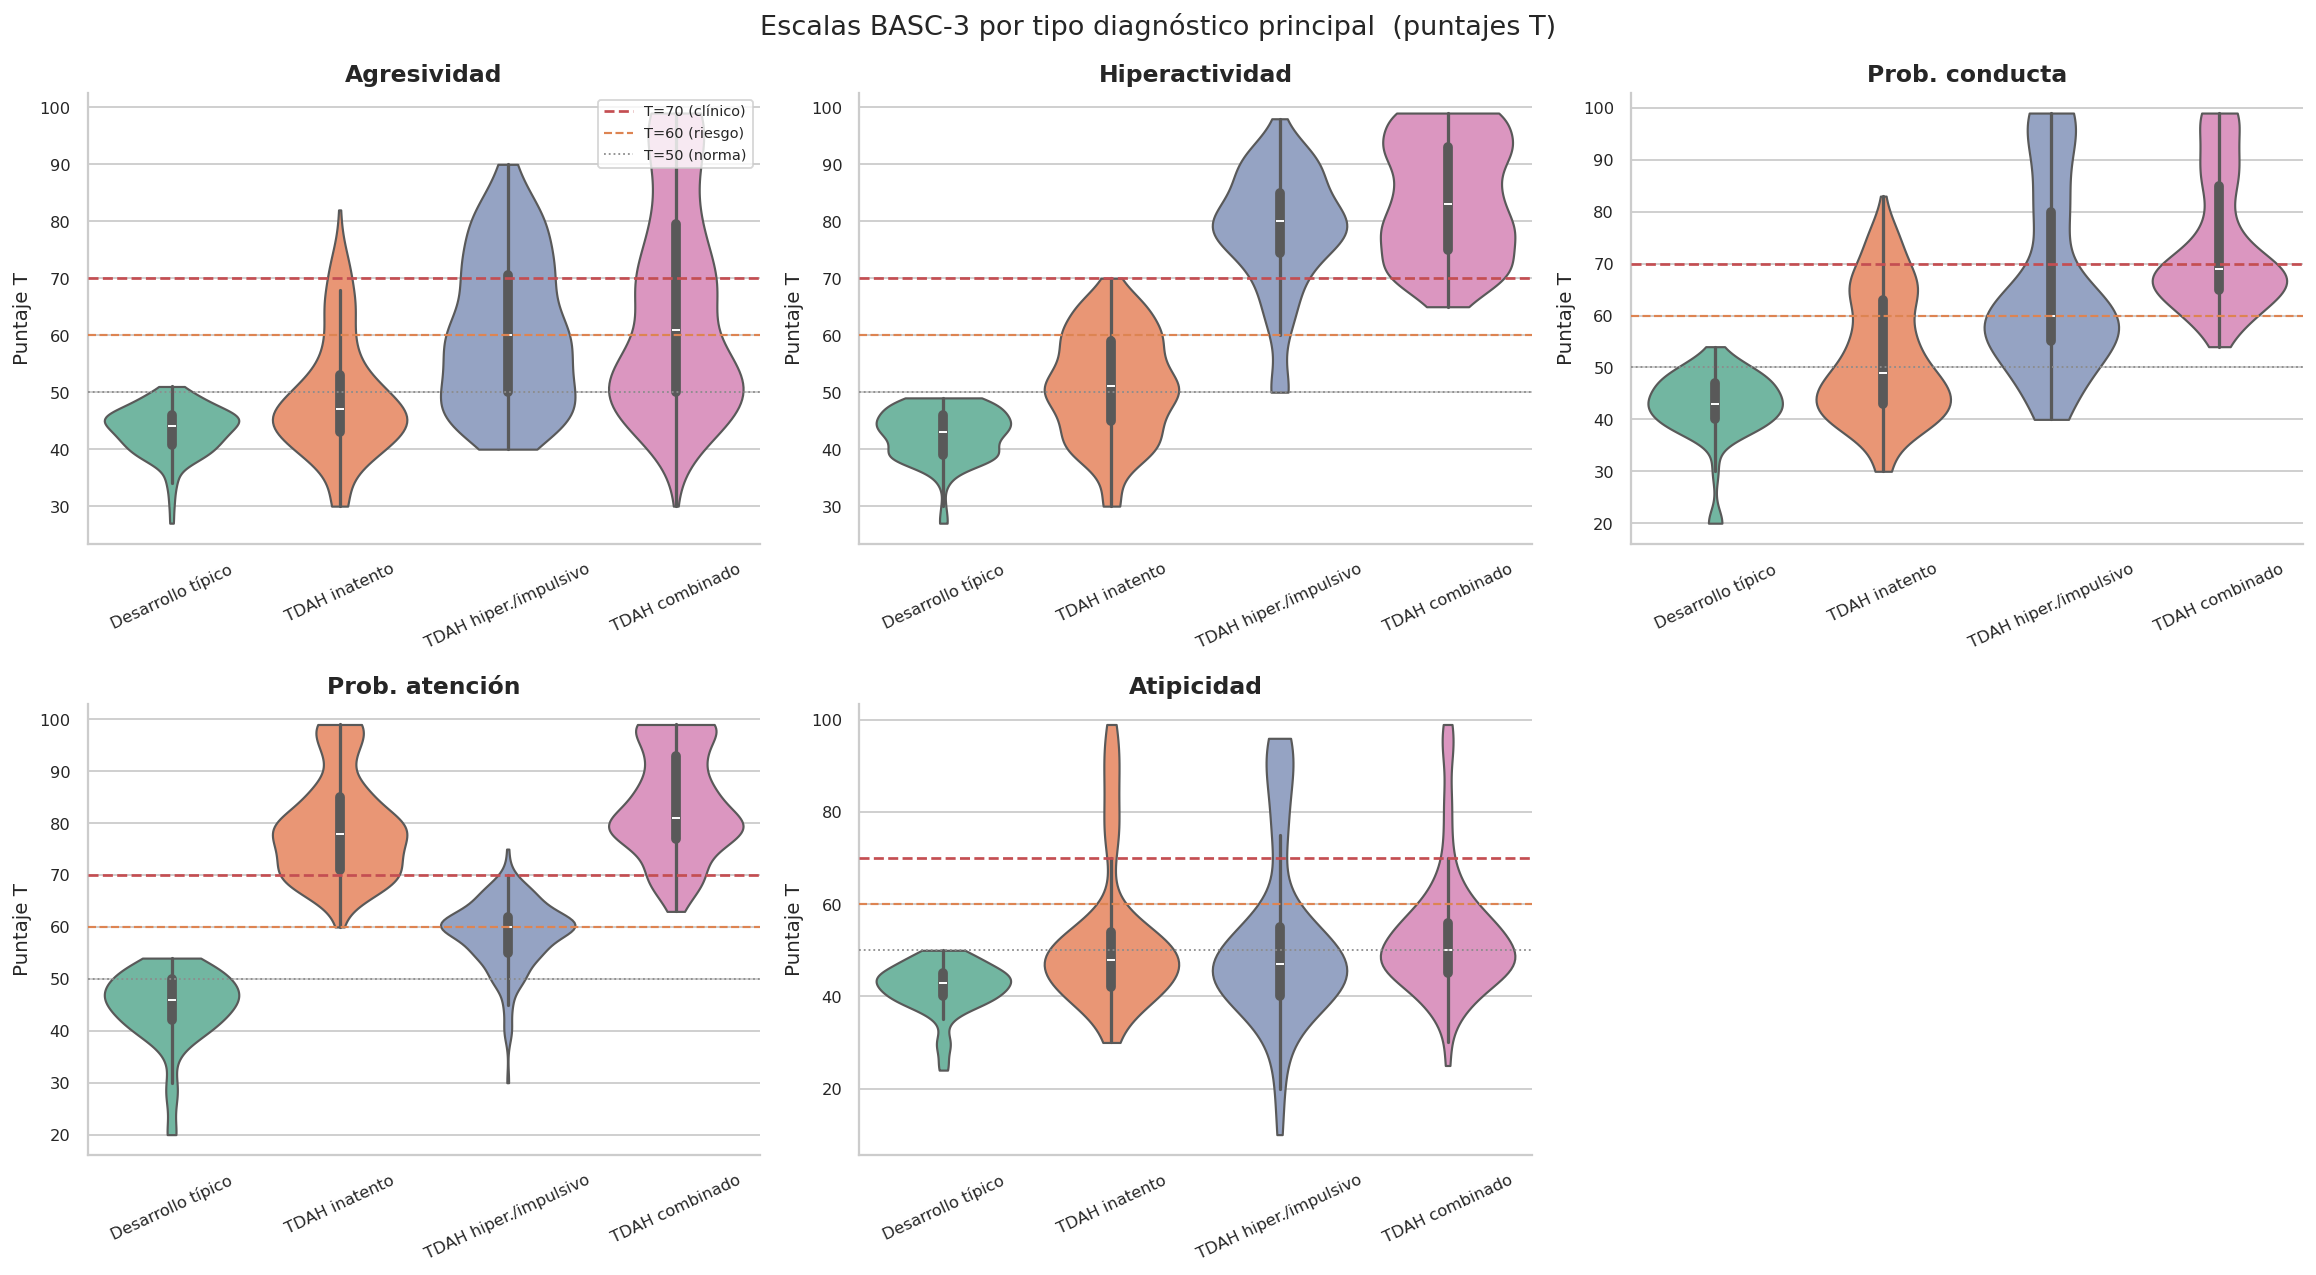

In [7]:
vars_basc   = ['agresividad_basc3', 'hiperactividad_basc3', 'problemas_conducta_basc3',
                'problemas_atencion_basc3', 'atipicidad_basc3']
labels_basc = ['Agresividad', 'Hiperactividad', 'Prob. conducta',
               'Prob. atención', 'Atipicidad']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Escalas BASC-3 por tipo diagnóstico principal  (puntajes T)", fontsize=15)
axes_flat = axes.flatten()

for i, (col, label) in enumerate(zip(vars_basc, labels_basc)):
    ax = axes_flat[i]
    sns.violinplot(data=df, x='tipo_tdah', y=col, order=ORDEN4,
                   palette=PAL4, inner='box', cut=0, ax=ax, linewidth=1.2)
    ax.axhline(70, color=C_RED, linestyle='--', linewidth=1.5, label='T=70 (clínico)', zorder=5)
    ax.axhline(60, color=C_ORG, linestyle='--', linewidth=1.2, label='T=60 (riesgo)', zorder=5)
    ax.axhline(50, color=C_GRAY, linestyle=':',  linewidth=1.0, label='T=50 (norma)',  zorder=5)
    ax.set_title(label); ax.set_xlabel(''); ax.set_ylabel('Puntaje T')
    ax.tick_params(axis='x', rotation=25)
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()


📋 **Interpretación — Violinplots BASC-3**

**Las tres líneas de referencia:**
- **T = 50** (gris punteada): media de la población normativa general (niños sin diagnóstico). Si un grupo está por encima de esta línea, su nivel medio ya supera a la mitad de la población típica.
- **T = 60** (naranja): umbral de *zona de riesgo*. Un puntaje aquí equivale a estar una desviación estándar por encima de la norma — ya es una señal de alerta clínica.
- **T = 70** (roja): umbral *clínicamente significativo*. Dos desviaciones estándar sobre la norma. A este nivel se suele justificar intervención activa.

**Qué esperar en cada grupo:**
- *Desarrollo típico*: la mayoría de los violines deberían concentrarse cerca de T=50 o por debajo de T=60. Este grupo actúa como referencia.
- *TDAH hiper./impulsivo y combinado*: se espera que **Hiperactividad** y **Problemas de conducta** sean especialmente elevados — es coherente con el perfil de hiperactividad.
- *TDAH inatento*: **Problemas de atención** debería destacar sobre las demás escalas.
- **Atipicidad** tiende a ser transversal — elevada en múltiples subtipos, especialmente en aquellos con comorbilidades como TEA o TND.

**Cómo comparar grupos dentro de un violín:** si el cuerpo del violín de un grupo se concentra mayoritariamente por encima de T=60, indica que la *mayoría* de los casos en ese grupo están en zona de riesgo clínico en esa dimensión.

In [8]:
kw_basc = test_kw(df, vars_basc)
print("Kruskal-Wallis — Escalas BASC-3")
display(kw_basc)


Kruskal-Wallis — Escalas BASC-3


,H (KW),p-valor,Significativo (α=0.05)
Variable,,,
agresividad_basc3,286.036,1.0466e-61,Sí
hiperactividad_basc3,650.946,9.0825e-141,Sí
problemas_conducta_basc3,419.107,1.6075e-90,Sí
problemas_atencion_basc3,596.322,6.3205e-129,Sí
atipicidad_basc3,94.434,2.4436e-20,Sí


📋 **Interpretación — Kruskal-Wallis BASC-3**

Las escalas con **H más alto y p-valor más bajo** son las que mejor discriminan entre tipos de TDAH. En este contexto clínico es razonable esperar que:

- **Hiperactividad BASC-3** tenga H elevado: separa claramente los subtipos con componente hiperactivo (combinado, hiper./impulsivo) de los que no lo tienen (inatento, típico).
- **Problemas de atención** también debería ser altamente discriminante: presente en todos los subtipos TDAH pero más pronunciado en el inatento.
- **Agresividad** y **Prob. conducta** pueden tener H moderado — estas escalas están más relacionadas con comorbilidades conductuales (TND) que con el subtipo de TDAH per se.
- **Atipicidad** es la más variable entre individuos (recordar que tuvo los más outliers IQR en el univariado), lo que puede moderar su H aunque sea clínicamente relevante.

Un resultado *no significativo* (p > 0.05) en alguna escala indicaría que esa dimensión del comportamiento es similar en todos los tipos — es información útil porque sugiere que esa característica no es específica del subtipo.

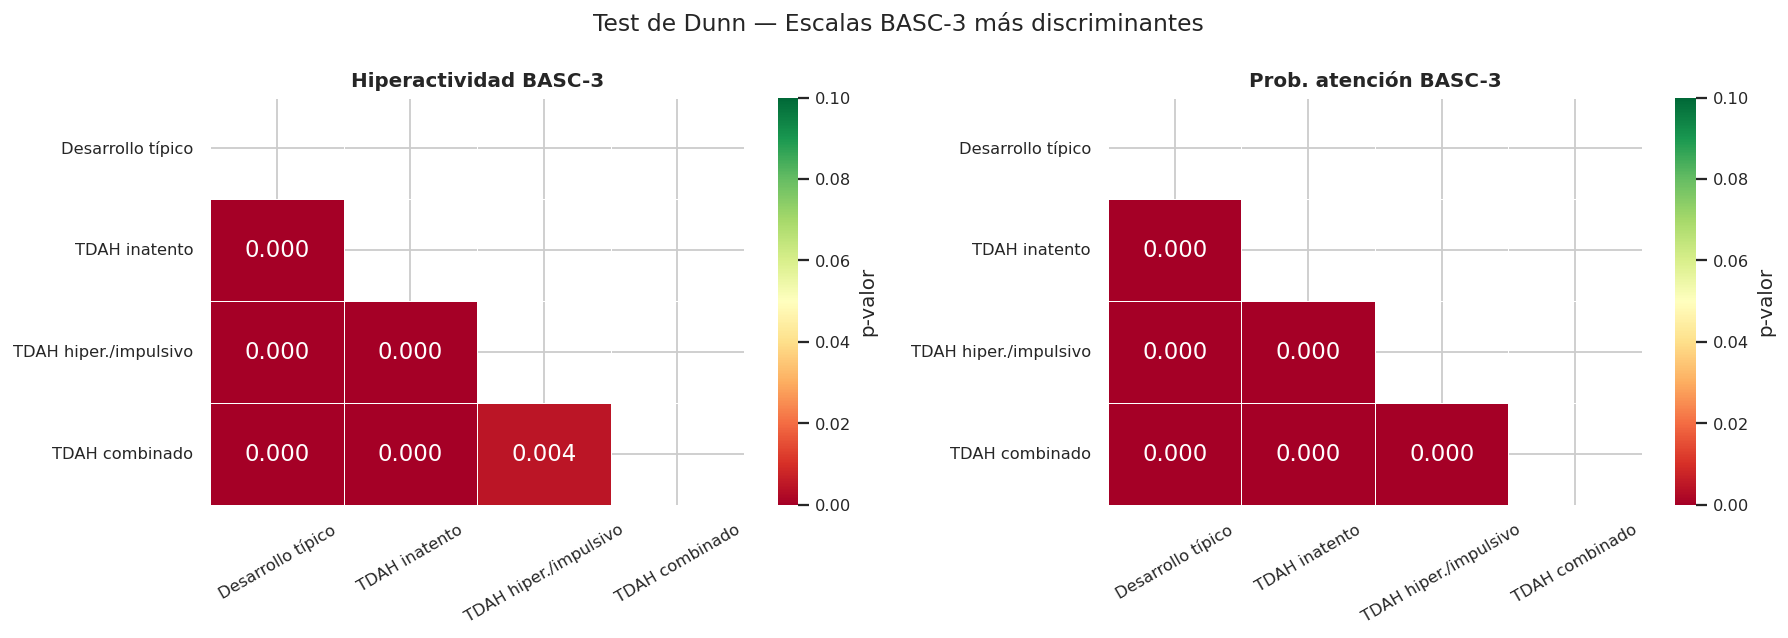

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test de Dunn — Escalas BASC-3 más discriminantes", fontsize=13)

dunn_heatmap(df, 'hiperactividad_basc3',    orden=ORDEN4, ax=axes[0], title='Hiperactividad BASC-3')
dunn_heatmap(df, 'problemas_atencion_basc3', orden=ORDEN4, ax=axes[1], title='Prob. atención BASC-3')

plt.tight_layout()
plt.show()


📋 **Interpretación — Dunn BASC-3**

Se muestran las dos escalas que se espera sean más discriminantes. La lectura es idéntica a la del Bloque 1:

**Hiperactividad BASC-3:** la clave aquí es observar si *Desarrollo típico* vs *TDAH combinado/hiper.* son rojos (diferencia grande), y si *TDAH inatento* vs *TDAH hiper./impulsivo* también lo son — dado que el inatento puro no debería tener hiperactividad conductual elevada.

**Problemas de atención BASC-3:** aquí el patrón esperado es diferente — todos los subtipos TDAH deberían tener problemas de atención elevados respecto a *Desarrollo típico*, pero las diferencias *entre* subtipos TDAH podrían ser menores. Si los tres subtipos TDAH son verdes entre sí en esta escala, significa que la dificultad atencional es transversal al TDAH independientemente del subtipo, lo cual es clínicamente coherente.

---
## Bloque 3 — CIT y fluidez fonológica vs etiqueta diagnóstica

**CIT (Coeficiente Intelectual Total):** medida estandarizada de capacidad cognitiva general, tipo escala Wechsler. En la población general se distribuye con media = 100 y DS = 15.

| Rango CIT | Clasificación |
|-----------|---------------|
| ≥ 130 | Muy superior |
| 120–129 | Superior |
| 110–119 | Promedio alto |
| 90–109 | **Promedio** |
| 80–89 | Bajo promedio |
| 70–79 | Límite |
| < 70 | Discapacidad intelectual |

**Fluidez fonológica:** número de palabras que el niño genera comenzando con una letra determinada en un tiempo limitado. Mide velocidad de acceso léxico, memoria de trabajo y función ejecutiva. No tiene un baremo fijo en este dataset — se interpreta de forma relativa entre grupos.

La línea de referencia en el gráfico del CIT se ubica en **90** (límite bajo promedio): por debajo de este valor las dificultades cognitivas empiezan a ser clínicamente relevantes.

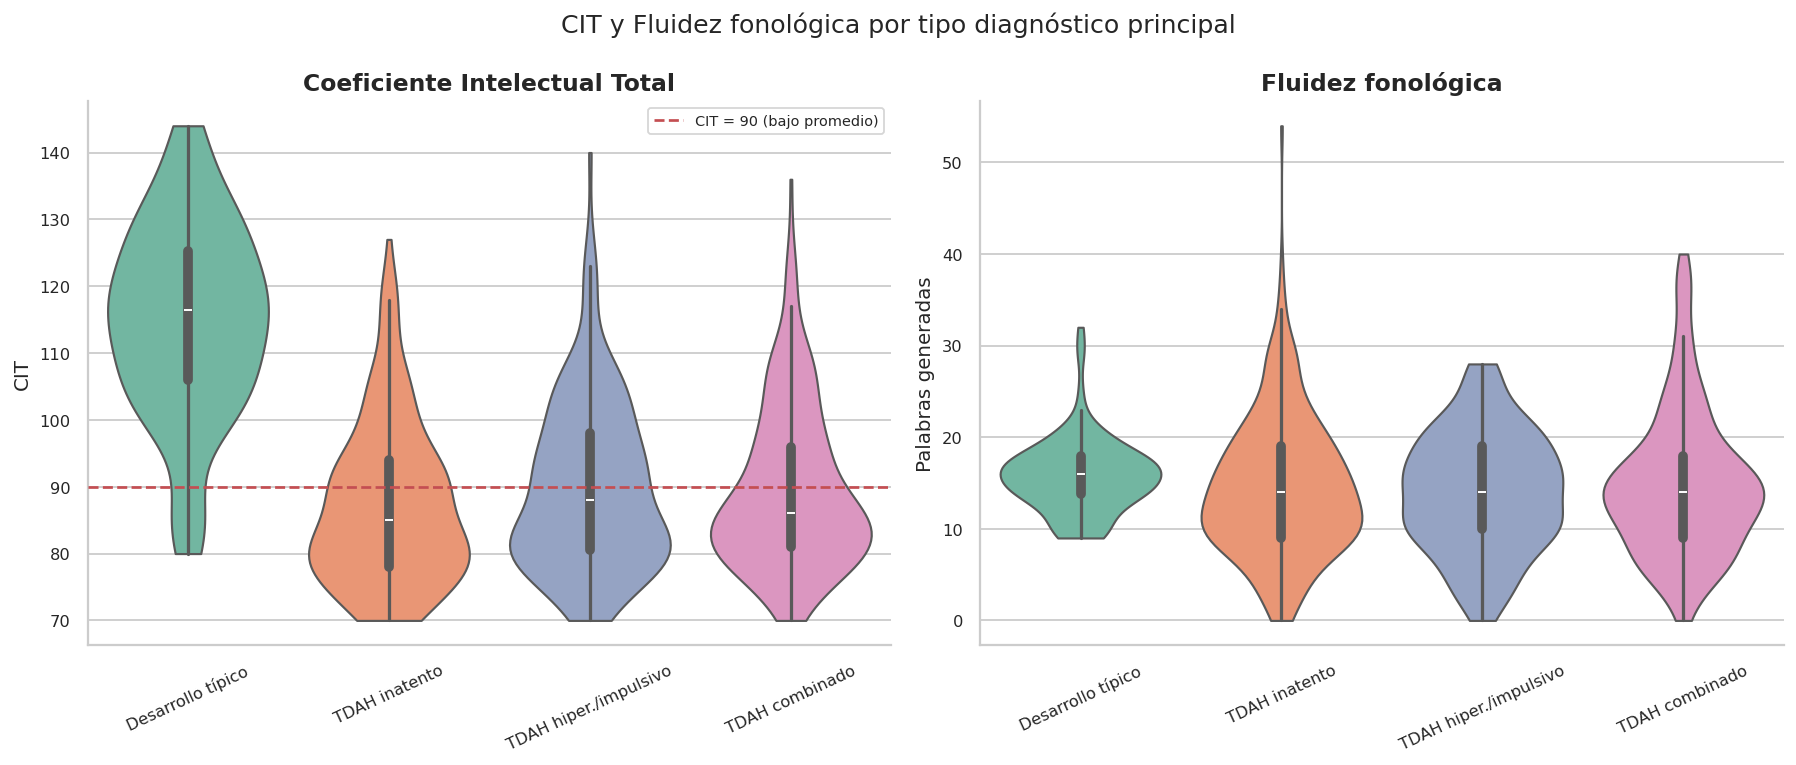

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("CIT y Fluidez fonológica por tipo diagnóstico principal", fontsize=14)

violin_strip(df, 'cit', orden=ORDEN4, ax=axes[0],
             ylabel='CIT', hline=90, hline_label='CIT = 90 (bajo promedio)')
axes[0].set_title('Coeficiente Intelectual Total')

violin_strip(df, 'fluidez_fonologica', orden=ORDEN4, ax=axes[1], ylabel='Palabras generadas')
axes[1].set_title('Fluidez fonológica')

plt.tight_layout()
plt.show()


📋 **Interpretación — CIT y Fluidez fonológica**

**CIT:** La línea roja en 90 marca el umbral bajo promedio. Lo que hay que observar:
- ¿Qué proporción del violín de cada grupo cae *por debajo* de 90? Si una parte considerable del violín de los grupos TDAH está bajo esa línea, indica que hay un subgrupo con dificultades cognitivas acompañando al TDAH.
- *Desarrollo típico* debería mostrar el CIT más centrado cerca de 100 o superior.
- Los subtipos con comorbilidades (en especial TEA y TEAZ, incluidos en el tipo "combinado" e "inatento" cuando se agrupan) suelen asociarse a CIT más variable o más bajo.
- Una diferencia grande entre *Desarrollo típico* y los grupos TDAH en CIT sería clínicamente importante: indicaría que el TDAH en esta muestra va acompañado de una reducción en la capacidad cognitiva general, más allá de lo esperable.

**Fluidez fonológica:** esta tarea es sensible a la función ejecutiva y al lenguaje. Se espera:
- *Desarrollo típico* con los puntajes más altos.
- Diferencias entre subtipos de TDAH que reflejen el grado de afectación ejecutiva: el subtipo combinado (más severo) podría mostrar puntajes más bajos.
- Recordar que hay casos con puntaje = 0 (detectados en el univariado). Es importante ver en qué grupos se concentran.

Kruskal-Wallis — CIT y Fluidez fonológica


,H (KW),p-valor,Significativo (α=0.05)
Variable,,,
cit,197.408,1.5320e-42,Sí
fluidez_fonologica,9.529,2.3030e-02,Sí


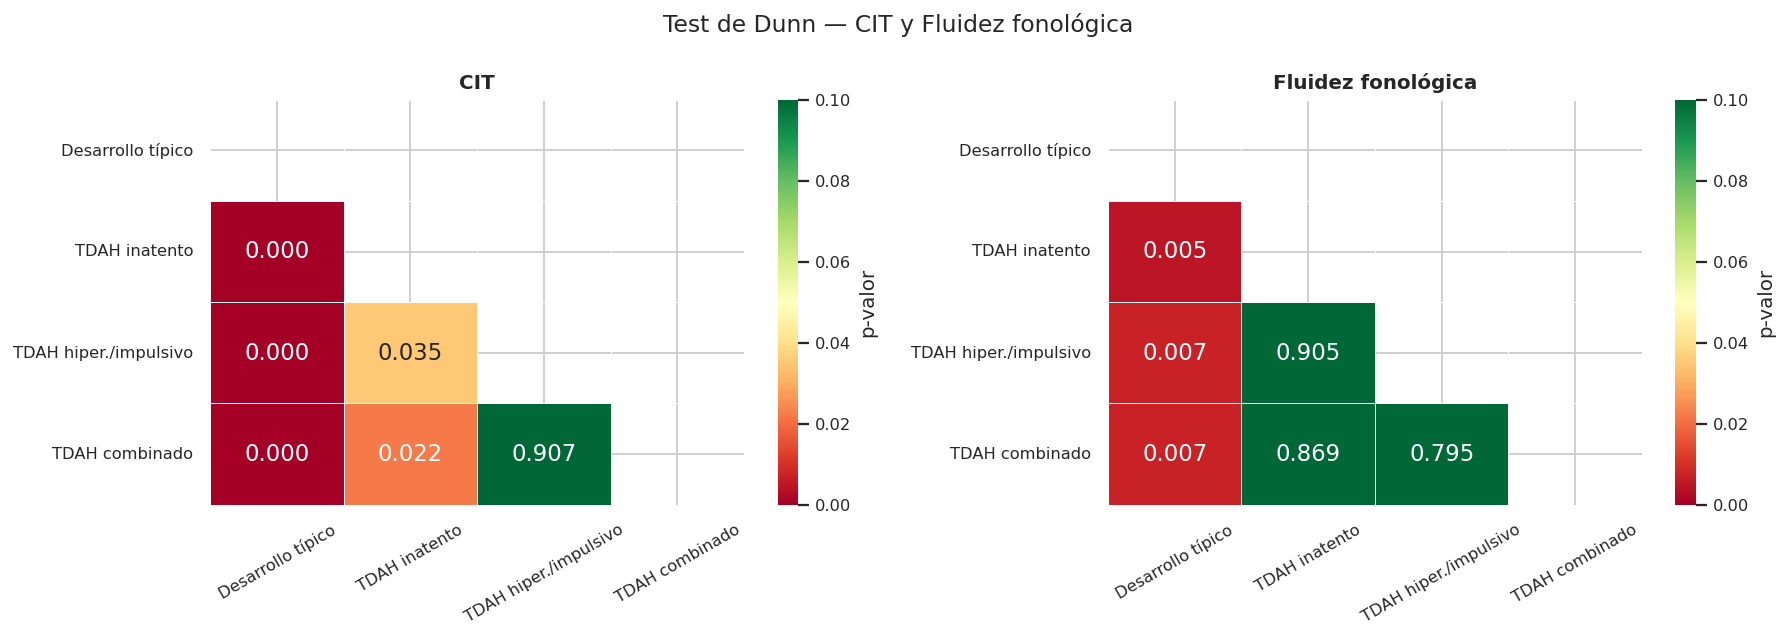

In [11]:
kw_cog = test_kw(df, ['cit', 'fluidez_fonologica'])
print("Kruskal-Wallis — CIT y Fluidez fonológica")
display(kw_cog)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test de Dunn — CIT y Fluidez fonológica", fontsize=13)
dunn_heatmap(df, 'cit',                orden=ORDEN4, ax=axes[0], title='CIT')
dunn_heatmap(df, 'fluidez_fonologica', orden=ORDEN4, ax=axes[1], title='Fluidez fonológica')
plt.tight_layout()
plt.show()


📋 **Interpretación — KW y Dunn (CIT y Fluidez)**

**Si el KW del CIT es significativo:** significa que al menos un par de tipos diagnósticos difiere en capacidad cognitiva general. El Dunn dirá cuáles. Lo más informativo es si *Desarrollo típico* difiere de los subtipos TDAH, y si hay diferencias *entre* los subtipos TDAH (lo que apuntaría a que la severidad cognitiva varía con el perfil clínico).

**Si el KW del CIT no es significativo:** indicaría que el CIT es similar entre grupos — es decir, que en esta muestra el TDAH no va necesariamente acompañado de un CIT diferente al del grupo de desarrollo típico. Esto es relevante porque rompe el mito de que el TDAH implica menor inteligencia.

**Fluidez fonológica:** si resulta significativa, el Dunn mostrará si las diferencias se concentran en la comparación típico vs TDAH (lo más esperado) o también entre subtipos TDAH. Un gradiente claro (típico > inatento > combinado) apoyaría que la función ejecutiva se deteriora con la complejidad del perfil diagnóstico.

---
## Bloque 4 — Variables demográficas vs etiqueta diagnóstica

### 4a. Edad y escolaridad (numéricas → Kruskal-Wallis)
### 4b. Sexo y lateralidad (categóricas → Chi-cuadrado)

Para las variables categóricas se usa el **test de Chi-cuadrado de independencia**, que evalúa si la distribución de una variable categórica (p.ej. sexo) es independiente del grupo diagnóstico. Un p < 0.05 indica que la proporción de hombres/mujeres no es la misma en todos los diagnósticos.

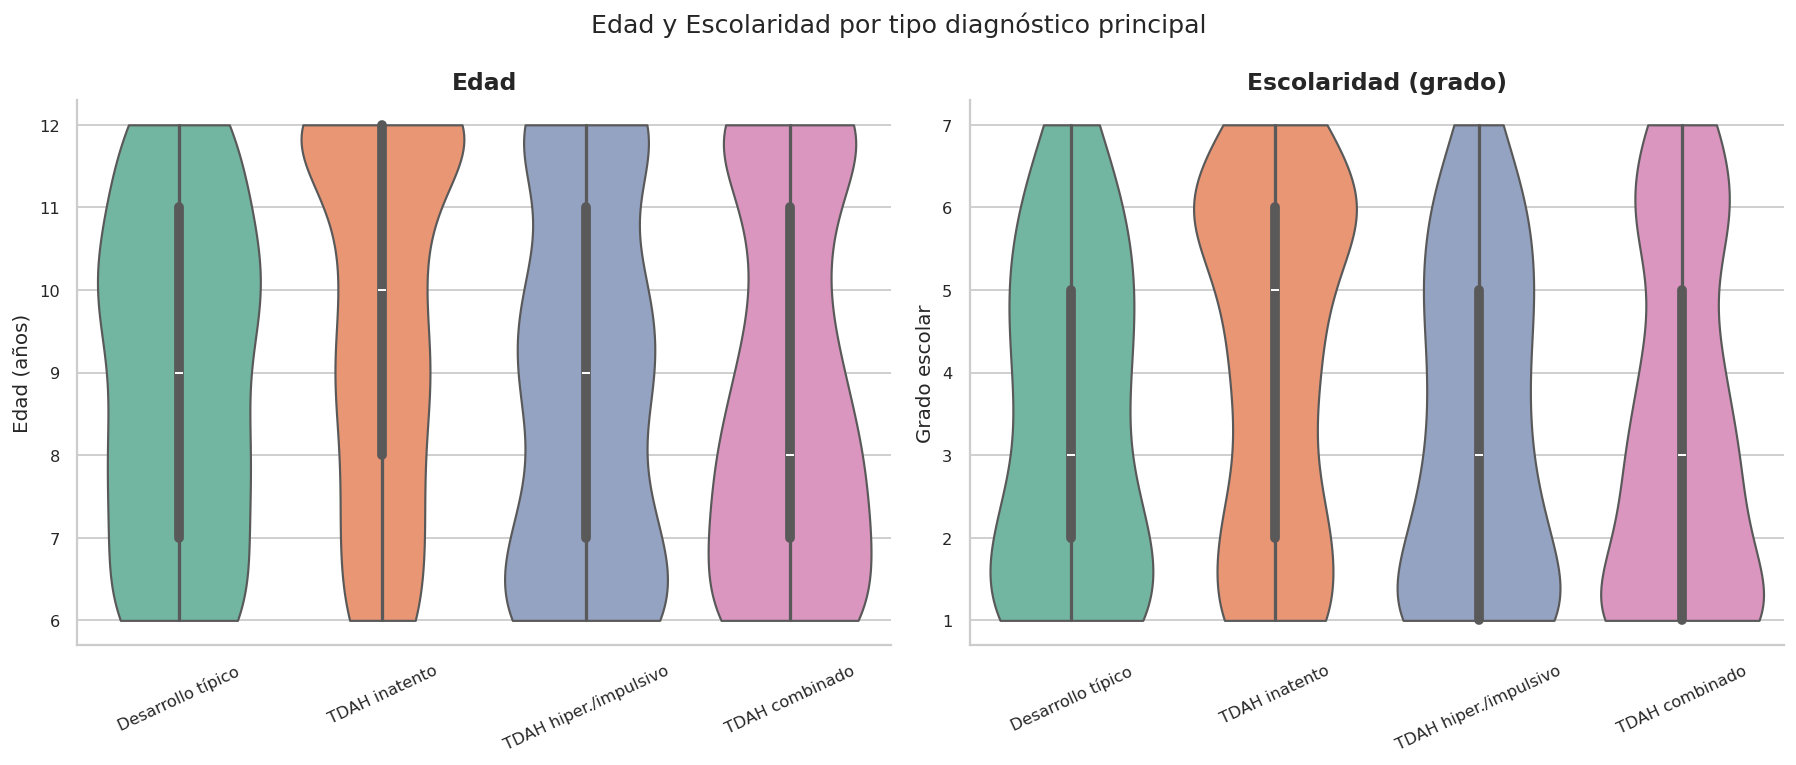

Kruskal-Wallis — Edad y Escolaridad


,H (KW),p-valor,Significativo (α=0.05)
Variable,,,
edad,26.909,6.1524e-06,Sí
escolaridad,28.676,2.6192e-06,Sí


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Edad y Escolaridad por tipo diagnóstico principal", fontsize=14)

violin_strip(df, 'edad',        orden=ORDEN4, ax=axes[0], ylabel='Edad (años)')
axes[0].set_title('Edad')

violin_strip(df, 'escolaridad', orden=ORDEN4, ax=axes[1], ylabel='Grado escolar')
axes[1].set_title('Escolaridad (grado)')

plt.tight_layout()
plt.show()

kw_dem = test_kw(df, ['edad', 'escolaridad'])
print("Kruskal-Wallis — Edad y Escolaridad")
display(kw_dem)


📋 **Interpretación — Edad y escolaridad**

**Edad:** en principio, no deberíamos esperar grandes diferencias de edad entre tipos diagnósticos en una muestra como esta, ya que el rango es estrecho (6–12 años) y el diagnóstico no depende de la edad dentro de ese rango. Sin embargo, si hay diferencias, podrían reflejar un sesgo de derivación: por ejemplo, que el subtipo inatento se diagnostica más tarde (en grados más avanzados, cuando las demandas académicas aumentan y la inatención se vuelve más evidente).

**Escolaridad:** está correlacionada con la edad por construcción (a mayor edad, mayor grado), por lo que si la edad no difiere entre grupos, la escolaridad tampoco debería. Si el test resultara significativo a pesar de esto, indicaría que hay diferencias en el historial escolar (p.ej. repetición de grado) entre tipos diagnósticos — un hallazgo clínicamente relevante.

Si ambas variables resultan *no significativas* (p > 0.05), confirma que la muestra está bien balanceada en términos de desarrollo y que las diferencias entre grupos no se explican por la edad.

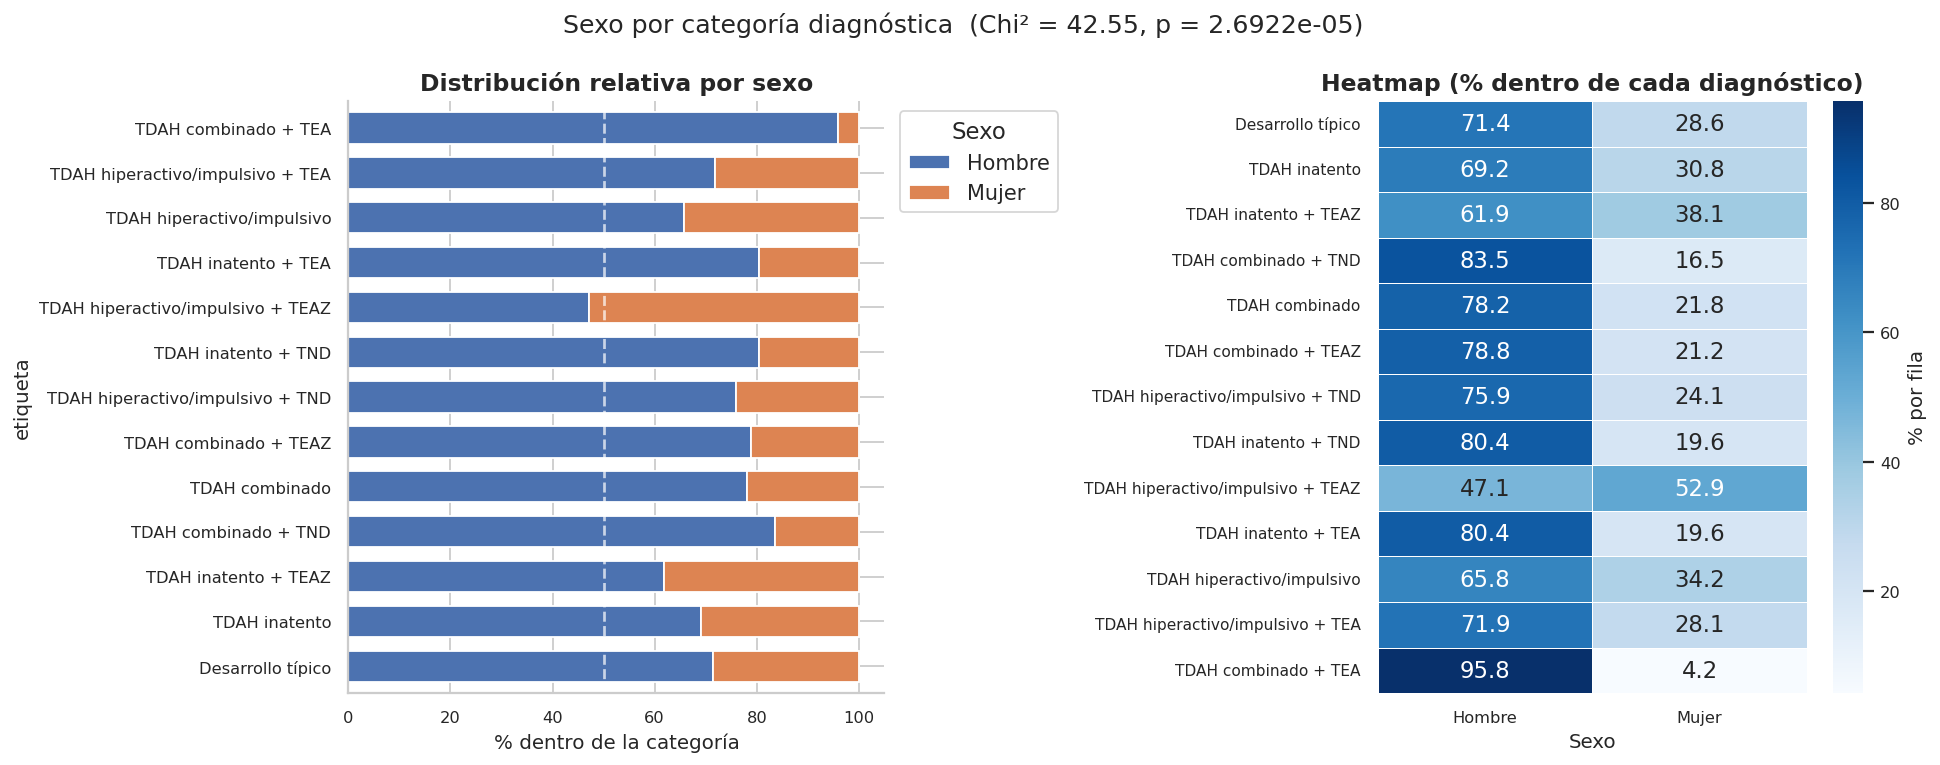

Chi-cuadrado: χ² = 42.548,  p = 2.6922e-05,  Significativo (α = 0.05)


In [13]:
chi2_sexo, p_sexo, _, _ = stats.chi2_contingency(
    pd.crosstab(df['etiqueta'], df['sexo'])
)
ct_sexo = pd.crosstab(df['etiqueta'], df['sexo'], normalize='index') * 100
ct_sexo = ct_sexo.reindex(df['etiqueta'].value_counts().index)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Sexo por categoría diagnóstica  (Chi² = {chi2_sexo:.2f}, p = {p_sexo:.4e})",
             fontsize=14)

ct_sexo.plot(kind='barh', stacked=True, ax=axes[0],
             color=[C_BLUE, C_ORG], edgecolor='white', width=0.7)
axes[0].set_xlabel('% dentro de la categoría')
axes[0].set_title('Distribución relativa por sexo')
axes[0].axvline(50, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].legend(title='Sexo', bbox_to_anchor=(1.01, 1))
axes[0].tick_params(axis='y', labelsize=9)

sns.heatmap(ct_sexo, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '% por fila'})
axes[1].set_title('Heatmap (% dentro de cada diagnóstico)')
axes[1].set_xlabel('Sexo'); axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.show()
print(f"Chi-cuadrado: χ² = {chi2_sexo:.3f},  p = {p_sexo:.4e},  "
      f"{'Significativo' if p_sexo < 0.05 else 'No significativo'} (α = 0.05)")


📋 **Interpretación — Sexo × diagnóstico**

**Cómo leer las barras apiladas:** cada barra representa el 100% de los casos de esa categoría diagnóstica. La porción azul es el % de hombres y la naranja el % de mujeres. La línea blanca en 50% es la referencia de paridad.

**Cómo leer el heatmap:** cada celda muestra el porcentaje de casos de ese diagnóstico que pertenecen a ese sexo. Las filas suman 100%. Una celda muy azul (porcentaje alto) significa que ese diagnóstico tiene mayor proporción de ese sexo.

**Contexto clínico:** en la muestra total hay un 73% de hombres (visto en el univariado). Esta proporción elevada es consistente con la epidemiología del TDAH: la prevalencia es entre 2 y 3 veces mayor en hombres que en mujeres en edad escolar, en parte porque los niños presentan síntomas más externalizados (hiperactividad, impulsividad) que son más fácilmente detectados y referidos. Las niñas tienden a presentar más el subtipo inatento, que es más silencioso.

**Si el test resulta significativo:** indicaría que la proporción hombre/mujer varía según el subtipo diagnóstico — por ejemplo, que el TDAH inatento tiene una mayor proporción de mujeres que el combinado. Esto sería coherente con la literatura.

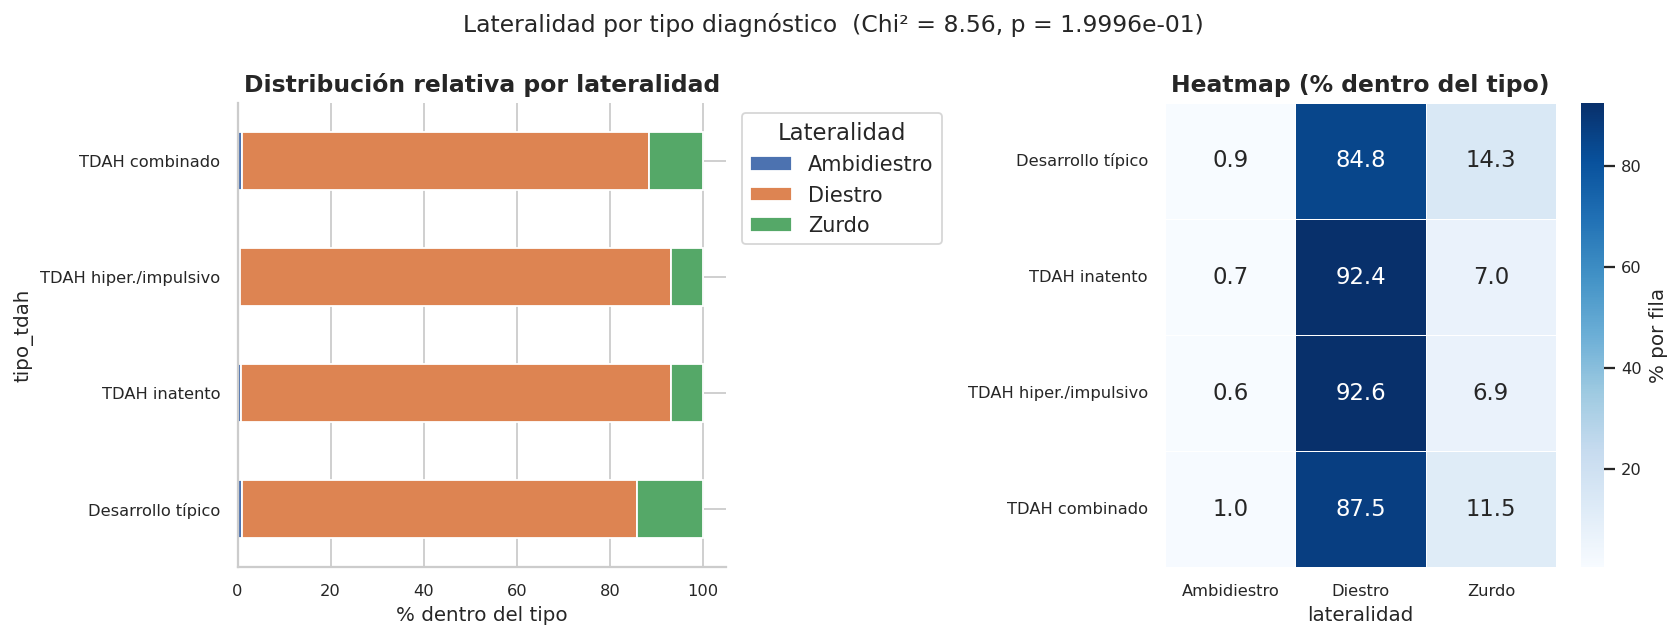

Chi-cuadrado: χ² = 8.559,  p = 1.9996e-01,  No significativo (α = 0.05)


In [14]:
chi2_lat, p_lat, _, _ = stats.chi2_contingency(
    pd.crosstab(df['tipo_tdah'], df['lateralidad'])
)
ct_lat = pd.crosstab(df['tipo_tdah'], df['lateralidad'], normalize='index') * 100
ct_lat = ct_lat.reindex(ORDEN4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Lateralidad por tipo diagnóstico  (Chi² = {chi2_lat:.2f}, p = {p_lat:.4e})",
             fontsize=13)

ct_lat.plot(kind='barh', stacked=True, ax=axes[0],
            color=[C_BLUE, C_ORG, C_GRN], edgecolor='white', width=0.5)
axes[0].set_xlabel('% dentro del tipo')
axes[0].set_title('Distribución relativa por lateralidad')
axes[0].legend(title='Lateralidad', bbox_to_anchor=(1.01, 1))

sns.heatmap(ct_lat, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '% por fila'})
axes[1].set_title('Heatmap (% dentro del tipo)'); axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print(f"Chi-cuadrado: χ² = {chi2_lat:.3f},  p = {p_lat:.4e},  "
      f"{'Significativo' if p_lat < 0.05 else 'No significativo'} (α = 0.05)")


📋 **Interpretación — Lateralidad × diagnóstico**

La muestra tiene un 90% de diestros (visto en el univariado), lo que refleja la prevalencia general de la lateralidad derecha en la población. Los zurdos y ambidiestros son muy pocos, lo que limita el poder estadístico de cualquier comparación.

**Si el test resulta no significativo (p > 0.05):** la lateralidad se distribuye igual en todos los grupos diagnósticos — lo más probable dado que no hay evidencia clínica sólida de que el TDAH esté asociado a lateralidad específica. Este sería un resultado esperado y sirve como *control de sanidad* del análisis.

**Si resultara significativo:** podría deberse al pequeño número de casos en algunas combinaciones (categorías raras) que generan desequilibrios artefactuales, más que a una relación real. En ese caso, el resultado debe interpretarse con cautela.

---
## Bloque 5 — Antecedentes clínicos vs etiqueta diagnóstica

Los tres antecedentes son variables nominales que describen el contexto clínico previo de cada paciente. Se analizan contra las 13 categorías diagnósticas para ver si ciertos antecedentes son más frecuentes en determinados subtipos.

**Cómo leer los heatmaps de contingencia:** cada fila corresponde a una categoría diagnóstica y cada columna a una categoría del antecedente. Los valores son **porcentajes por fila** — es decir, del total de casos con ese diagnóstico, qué % tiene cada tipo de antecedente. Las filas suman 100%. Un color intenso en una celda indica que ese antecedente es especialmente prevalente en ese diagnóstico.

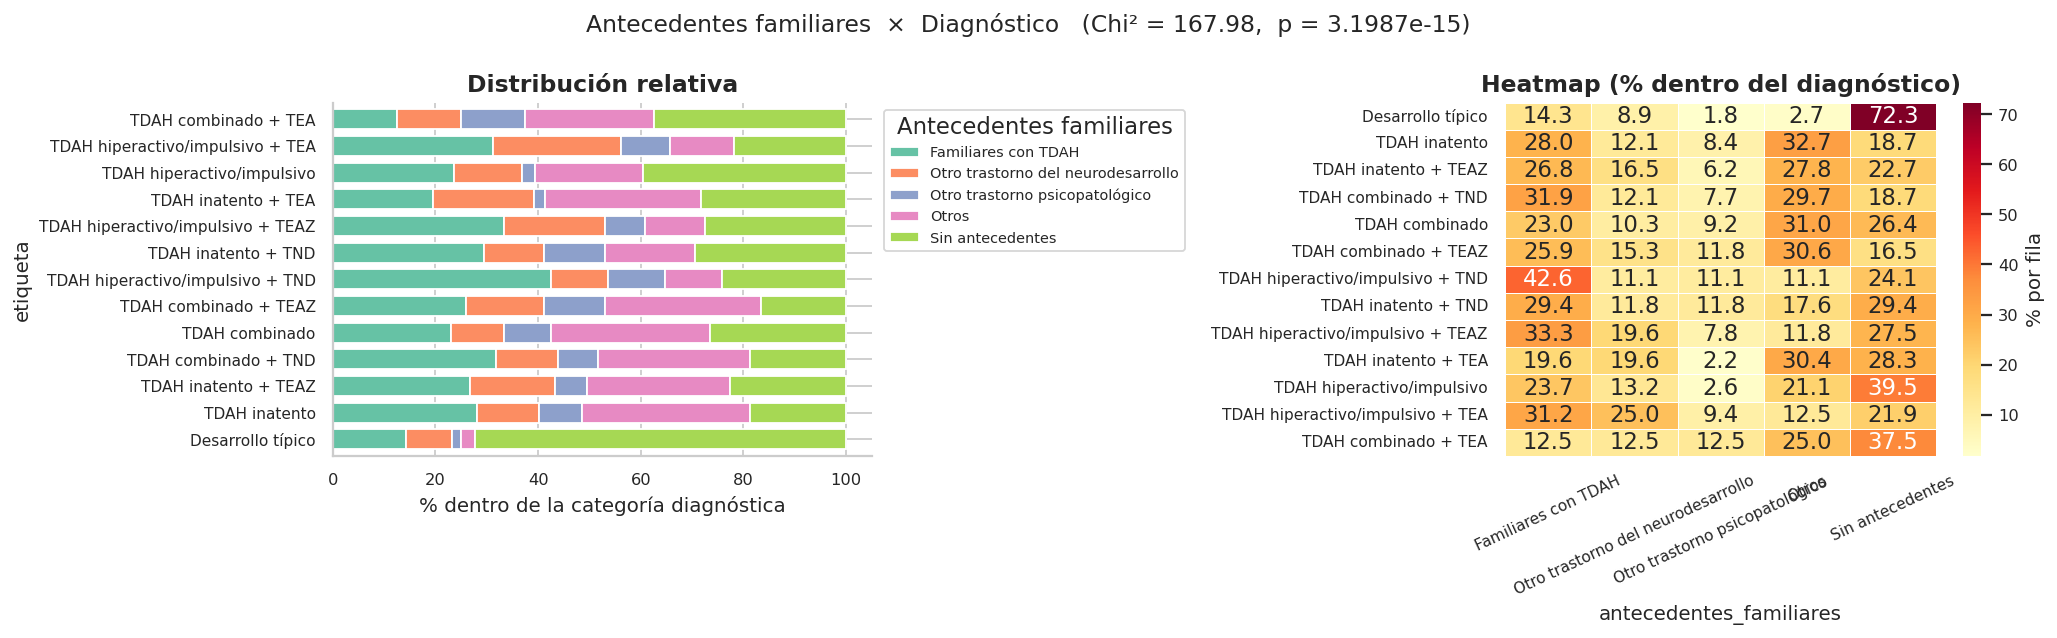

  Antecedentes familiares: χ² = 167.979,  p = 3.1987e-15  → Significativo



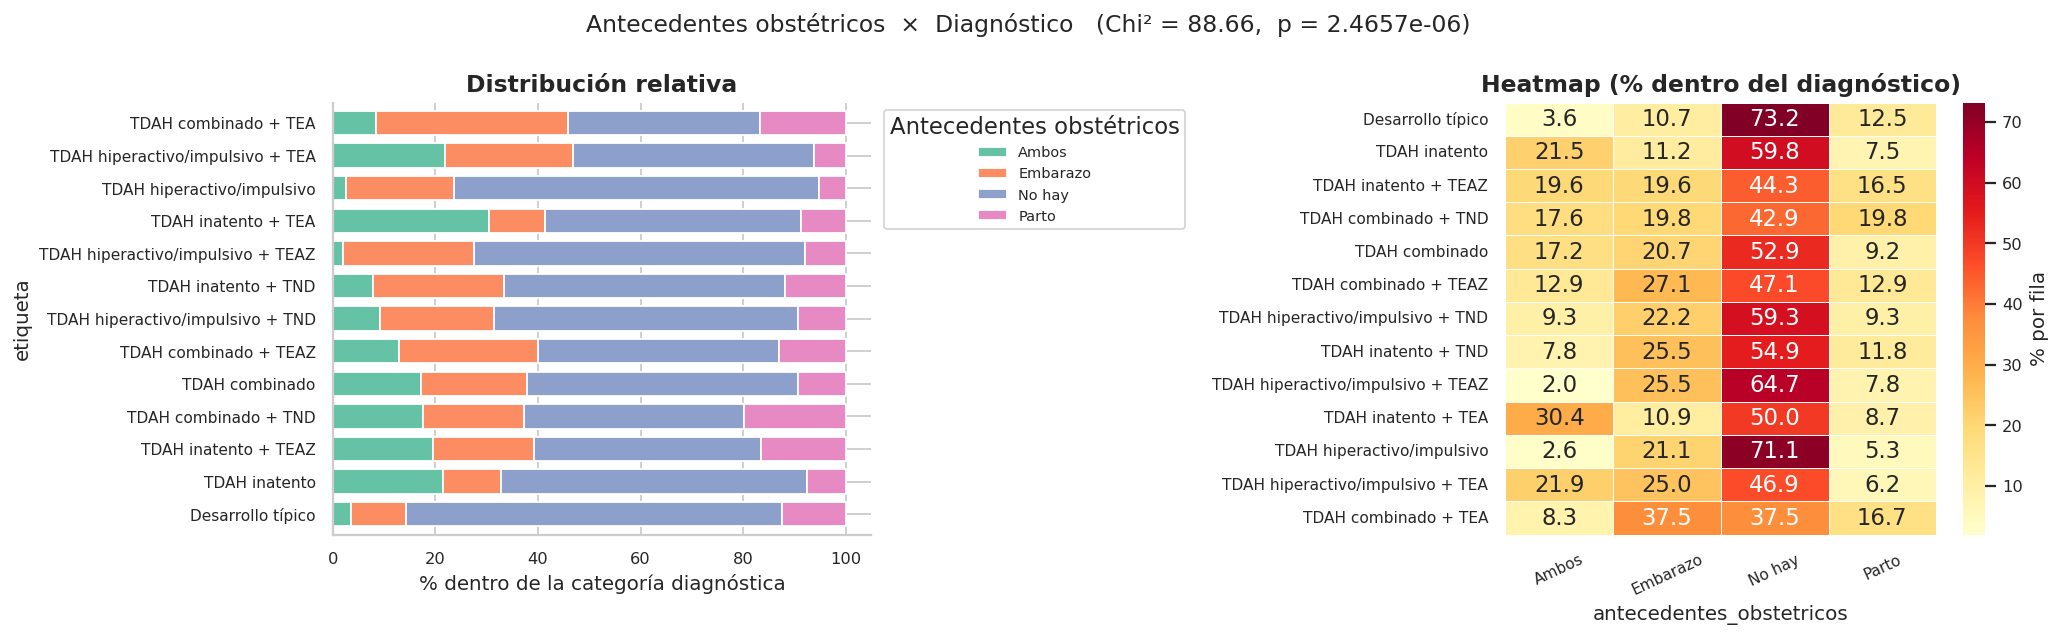

  Antecedentes obstétricos: χ² = 88.659,  p = 2.4657e-06  → Significativo



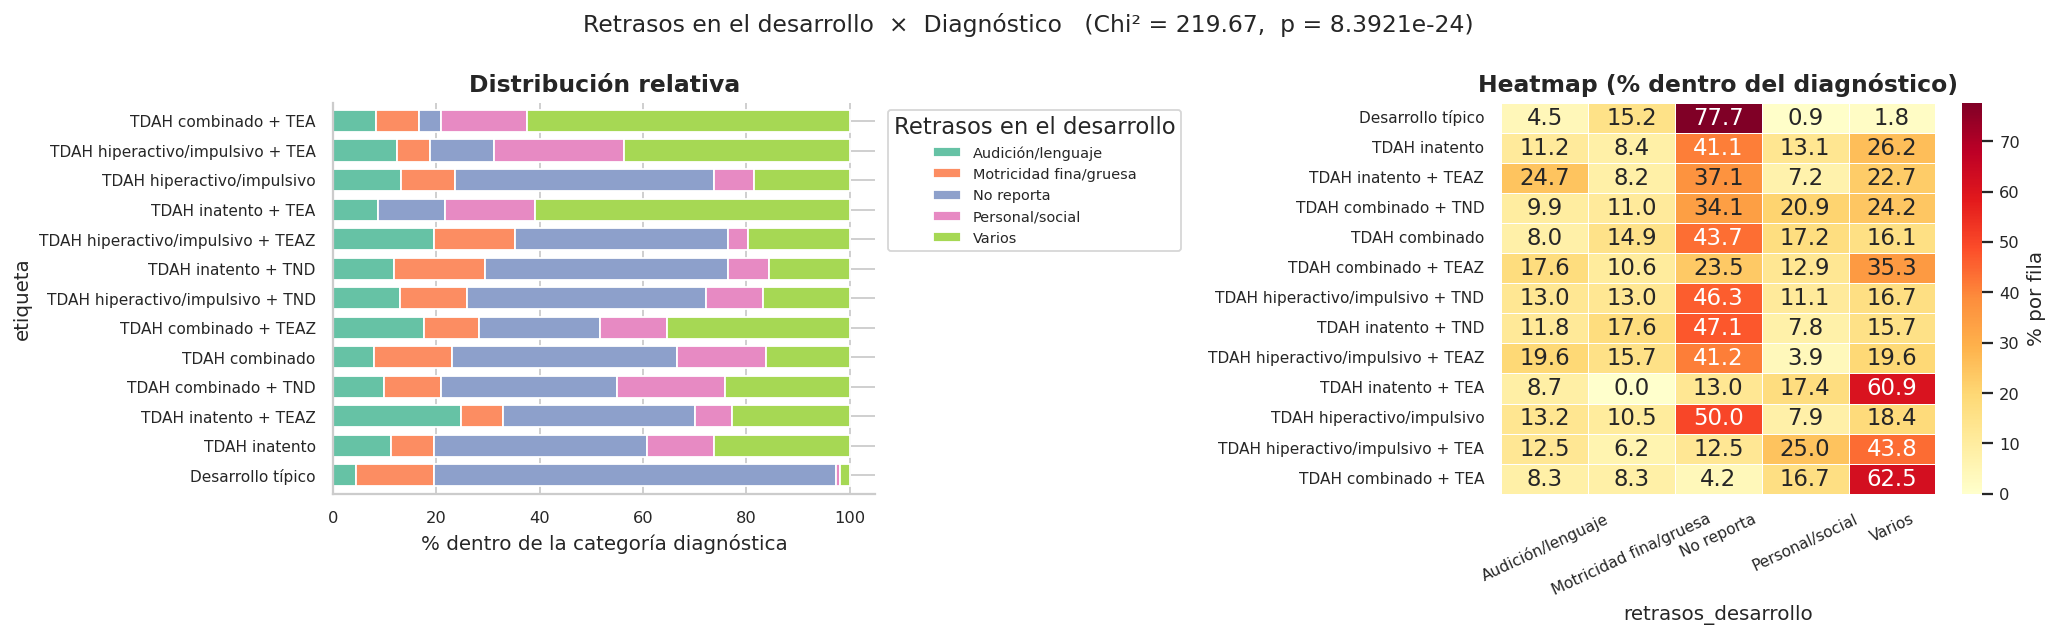

  Retrasos en el desarrollo: χ² = 219.674,  p = 8.3921e-24  → Significativo



In [15]:
antecedentes_meta = {
    'antecedentes_familiares':  'Antecedentes familiares',
    'antecedentes_obstetricos': 'Antecedentes obstétricos',
    'retrasos_desarrollo':      'Retrasos en el desarrollo',
}

for col, titulo in antecedentes_meta.items():
    ct = pd.crosstab(df['etiqueta'], df[col], normalize='index') * 100
    ct = ct.reindex(df['etiqueta'].value_counts().index)
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df['etiqueta'], df[col]))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"{titulo}  ×  Diagnóstico   (Chi² = {chi2:.2f},  p = {p:.4e})", fontsize=13)

    ct.plot(kind='barh', stacked=True, ax=axes[0],
            color=sns.color_palette("Set2", ct.shape[1]),
            edgecolor='white', width=0.75)
    axes[0].set_xlabel('% dentro de la categoría diagnóstica')
    axes[0].set_title('Distribución relativa')
    axes[0].legend(title=titulo, bbox_to_anchor=(1.01, 1), fontsize=8)
    axes[0].tick_params(axis='y', labelsize=8.5)

    sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
                linewidths=0.4, cbar_kws={'label': '% por fila'})
    axes[1].set_title('Heatmap (% dentro del diagnóstico)')
    axes[1].set_ylabel('')
    axes[1].tick_params(axis='y', labelsize=8.5)
    axes[1].tick_params(axis='x', rotation=25, labelsize=8.5)

    plt.tight_layout()
    plt.show()
    sig = 'Significativo' if p < 0.05 else 'No significativo'
    print(f"  {titulo}: χ² = {chi2:.3f},  p = {p:.4e}  → {sig}\n")


📋 **Interpretación — Antecedentes clínicos × diagnóstico**

**Antecedentes familiares:** se espera que los diagnósticos con componente más genético (TDAH puro, sin comorbilidades) tengan mayor proporción de "Familiares con TDAH", mientras que los subtipos con TEA o TND podrían tener mayor proporción de "Otro trastorno del neurodesarrollo" en la familia. Si el test es significativo, indica que el perfil familiar varía sistemáticamente según el subtipo diagnóstico del niño.

**Antecedentes obstétricos:** complicaciones en el embarazo o el parto se asocian a mayor riesgo de TDAH y otras condiciones del neurodesarrollo. Si ciertos subtipos (p.ej. los que tienen comorbilidades) muestran mayor proporción de "Embarazo" o "Parto" complicado, apuntaría a que el factor perinatal diferencia los perfiles más severos o complejos.

**Retrasos en el desarrollo:** los retrasos en habla/lenguaje (*Audición/lenguaje*) o en motricidad podrían ser más prevalentes en subtipos con comorbilidades como TEAZ (trastorno del espectro autista con zona) o TEA. Si el test es significativo y el heatmap muestra que ciertos diagnósticos tienen más "Audición/lenguaje" o "Varios", refuerza la idea de que esas categorías representen perfiles clínicamente más complejos desde el desarrollo temprano.

> **Sobre el chi-cuadrado con tablas grandes:** con 13 categorías diagnósticas y 4–5 categorías de antecedentes, el test tiene muchos grados de libertad. Un resultado significativo indica que *en algún lugar* de la tabla hay una asociación, pero no dice dónde. El heatmap es la herramienta para identificar visualmente cuáles combinaciones son las más llamativas.

---
## Bloque 6 — Perfil clínico global por categoría diagnóstica

Este bloque sintetiza el análisis bivariado completo en tres visualizaciones complementarias. Cada una tiene fortalezas distintas — leerlas juntas da una imagen más completa que cualquiera por separado.

---
### 6a. Heatmap de z-scores (13 categorías × 12 variables)

Muestra la **desviación de la media global** de cada variable para cada categoría diagnóstica, expresada en z-scores:
- **z = 0**: esa categoría tiene exactamente la media de toda la muestra en esa variable
- **z > 0 (rojo)**: esa categoría tiene un valor *mayor* que la media muestral
- **z < 0 (azul)**: esa categoría tiene un valor *menor* que la media muestral

Las líneas blancas separan los 4 tipos principales.

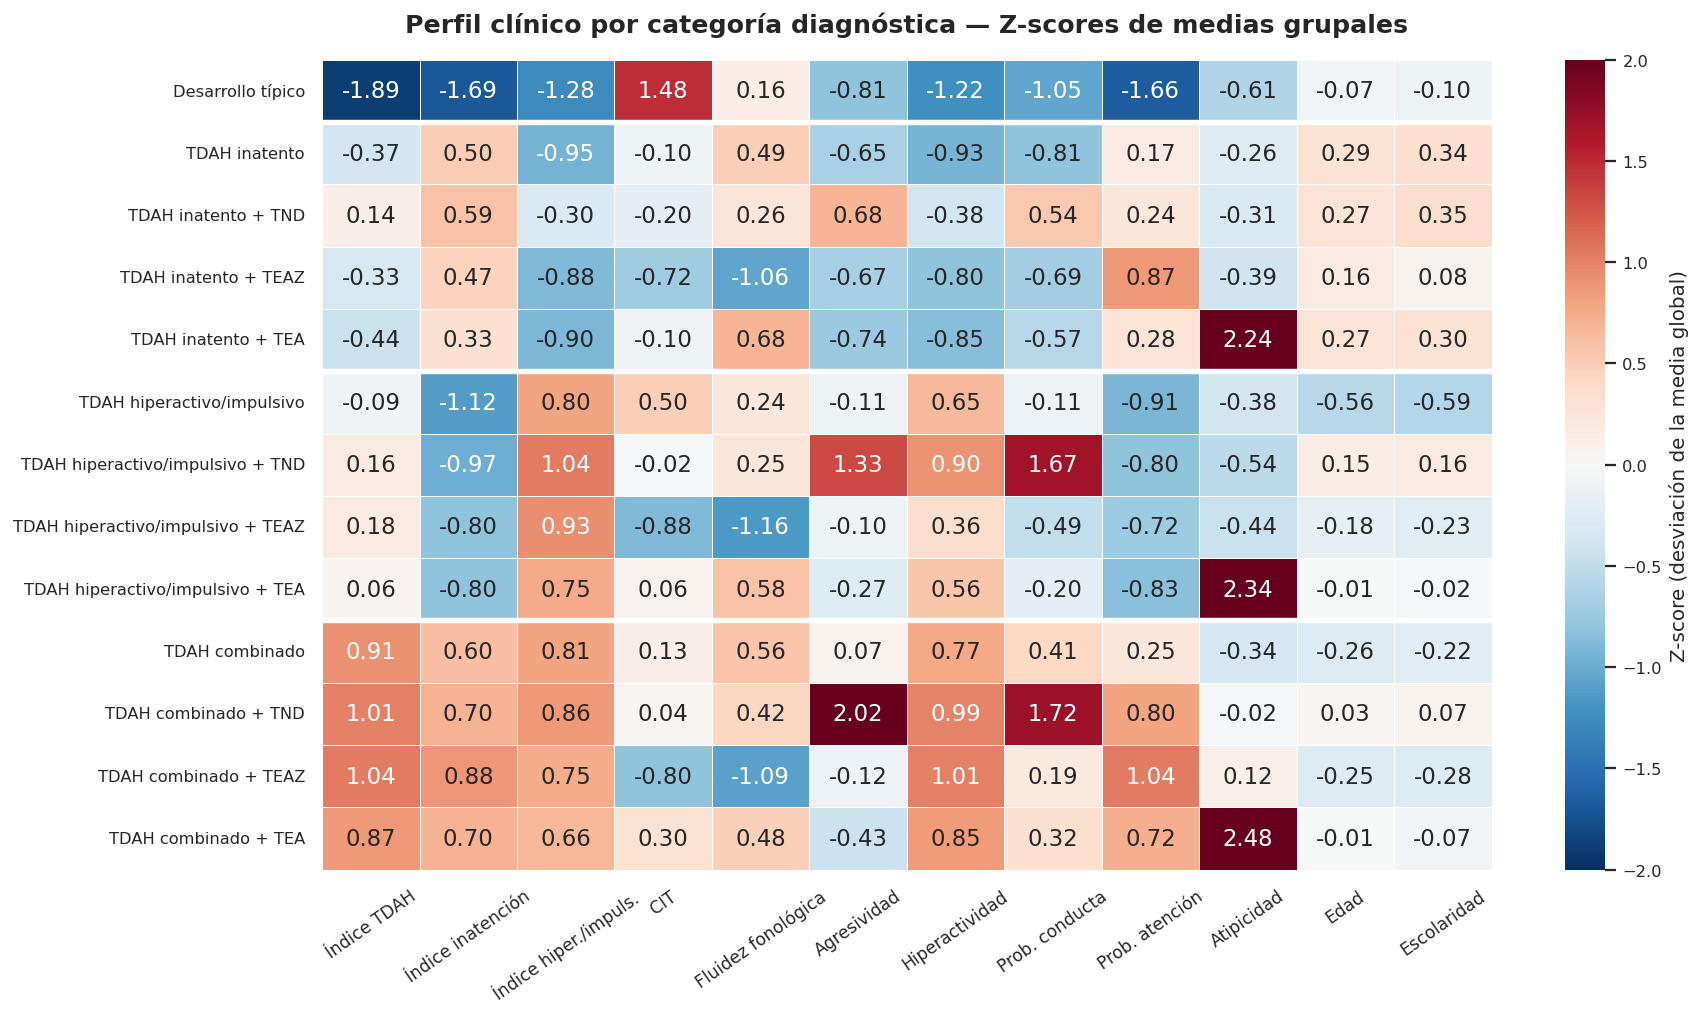

In [16]:
vars_num = ['indice_tdah', 'indice_inatencion', 'indice_impuls_hiperac',
            'cit', 'fluidez_fonologica',
            'agresividad_basc3', 'hiperactividad_basc3', 'problemas_conducta_basc3',
            'problemas_atencion_basc3', 'atipicidad_basc3',
            'edad', 'escolaridad']

labels_num = ['Índice TDAH', 'Índice inatención', 'Índice hiper./impuls.',
              'CIT', 'Fluidez fonológica',
              'Agresividad', 'Hiperactividad', 'Prob. conducta',
              'Prob. atención', 'Atipicidad',
              'Edad', 'Escolaridad']

medias_cat = df.groupby('etiqueta')[vars_num].mean()
z_scores   = (medias_cat - df[vars_num].mean()) / df[vars_num].std()
z_scores.columns = labels_num

orden_cat13 = [
    'Desarrollo típico',
    'TDAH inatento', 'TDAH inatento + TND', 'TDAH inatento + TEAZ', 'TDAH inatento + TEA',
    'TDAH hiperactivo/impulsivo', 'TDAH hiperactivo/impulsivo + TND',
    'TDAH hiperactivo/impulsivo + TEAZ', 'TDAH hiperactivo/impulsivo + TEA',
    'TDAH combinado', 'TDAH combinado + TND', 'TDAH combinado + TEAZ', 'TDAH combinado + TEA',
]
orden_cat13 = [c for c in orden_cat13 if c in z_scores.index]
z_scores = z_scores.reindex(orden_cat13)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(z_scores, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-2, vmax=2, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Z-score (desviación de la media global)'})
ax.set_title("Perfil clínico por categoría diagnóstica — Z-scores de medias grupales",
             fontsize=14, pad=15)
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=35, labelsize=9.5)
ax.tick_params(axis='y', rotation=0, labelsize=9)

separadores = [1, 5, 9]
for sep in separadores:
    ax.axhline(sep, color='white', linewidth=3)

plt.tight_layout()
plt.show()


📋 **Interpretación — Heatmap de z-scores**

**Cómo leerlo:** cada fila es una categoría diagnóstica y cada columna una variable clínica. El color representa cuánto se aleja esa categoría del promedio general de la muestra *en esa variable*.

**Qué buscar:**

- **Columnas de Índice inatención e Índice hiper./impuls.:** deberían mostrar el patrón más claro. Las filas de "TDAH inatento" deberían ser intensamente rojas en inatención y azules en hiperactividad; las de "hiperactivo/impulsivo", el patrón inverso. El "combinado" debería ser rojo en ambas.

- **Desarrollo típico (primera fila):** debería ser la más azul — especialmente en los índices TDAH y en las escalas BASC-3 que miden problemas de conducta y atención. Su CIT debería ser igual o superior a la media.

- **Subtipos con comorbilidades (+ TEA, + TND, + TEAZ):** comparar cada subtipo puro contra su versión con comorbilidad. Si la comorbilidad eleva ciertas escalas (p.ej. atipicidad o agresividad), las filas "+ comorbilidad" serán más rojas en esas columnas que el subtipo puro.

- **Las líneas blancas** separan los bloques de los 4 tipos principales, facilitando la comparación entre el subtipo puro y sus variantes con comorbilidades.

**Limitación:** este heatmap muestra *medias*, lo que puede suavizar la variabilidad interna de cada grupo. Un grupo puede tener z-score cercano a 0 porque sus casos se distribuyen simétricamente a ambos lados de la media, no necesariamente porque todos sus miembros sean "promedio".

---
### 6b. Radar chart — 4 tipos principales

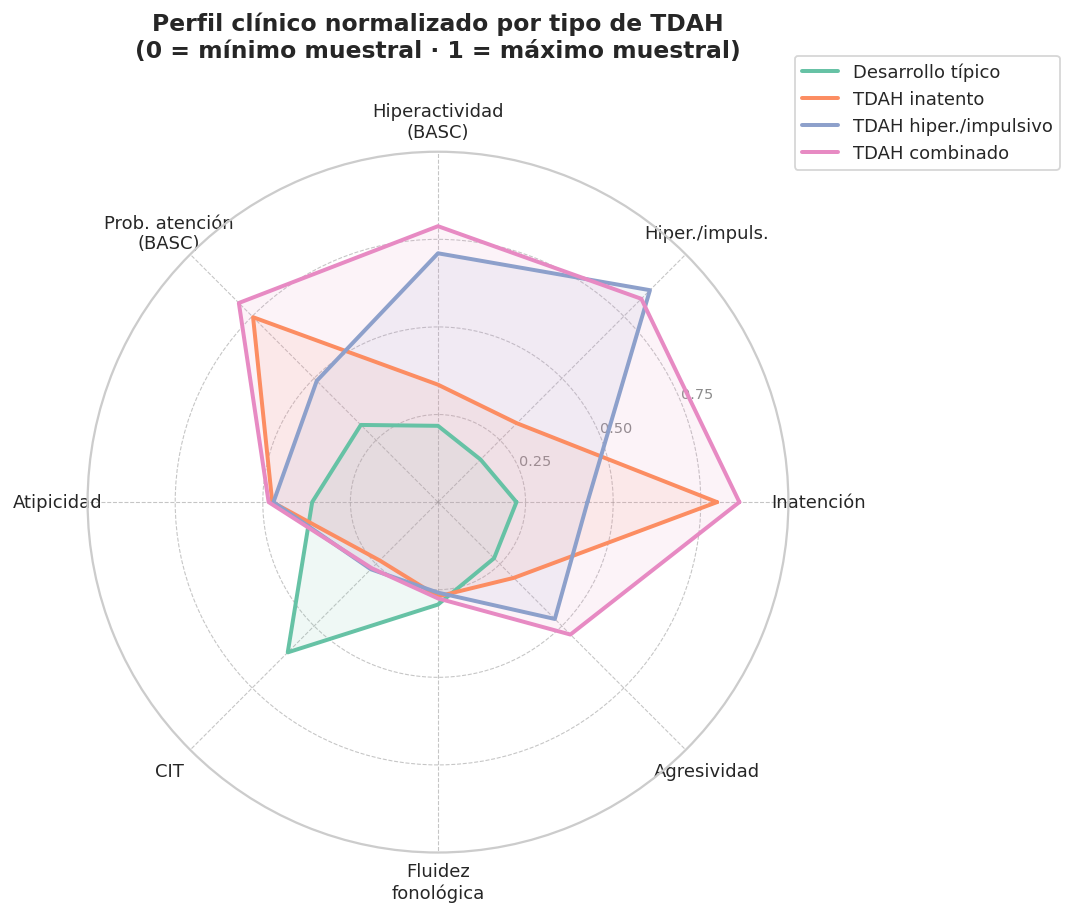

In [17]:
vars_radar = ['indice_inatencion', 'indice_impuls_hiperac',
              'hiperactividad_basc3', 'problemas_atencion_basc3', 'atipicidad_basc3',
              'cit', 'fluidez_fonologica', 'agresividad_basc3']
labels_radar = ['Inatención', 'Hiper./impuls.',
                'Hiperactividad\n(BASC)', 'Prob. atención\n(BASC)', 'Atipicidad',
                'CIT', 'Fluidez\nfonológica', 'Agresividad']

medias4 = df.groupby('tipo_tdah')[vars_radar].mean().reindex(ORDEN4)
mn = df[vars_radar].min()
mx = df[vars_radar].max()
norm4 = (medias4 - mn) / (mx - mn)

N      = len(vars_radar)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, tipo in enumerate(ORDEN4):
    vals = norm4.loc[tipo].tolist()
    vals += vals[:1]
    ax.plot(angulos, vals, linewidth=2.2, color=PAL4[i], label=tipo)
    ax.fill(angulos, vals, alpha=0.10, color=PAL4[i])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(labels_radar, size=10)
ax.set_yticks([0.25, 0.50, 0.75])
ax.set_yticklabels(['0.25', '0.50', '0.75'], size=8, color=C_GRAY)
ax.set_ylim(0, 1)
ax.set_title("Perfil clínico normalizado por tipo de TDAH\n(0 = mínimo muestral · 1 = máximo muestral)",
             fontsize=13, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=10)
ax.grid(color=C_GRAY, linestyle='--', linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.show()


📋 **Interpretación — Radar chart**

**Escala:** cada variable está normalizada entre 0 y 1 usando el mínimo y máximo *de la muestra* (no de la población general). Esto significa que **0 = el grupo con la media más baja** y **1 = el grupo con la media más alta** en esa variable dentro de esta muestra. No es una comparación contra un baremo externo.

**Cómo leer las formas:**
- Un polígono *grande* en una dimensión indica que ese grupo tiene valores altos en esa variable.
- Un polígono *pequeño* indica valores bajos.
- Si dos polígonos se *solapan* en una variable, los dos grupos tienen perfiles similares en esa dimensión — no es un buen discriminador entre ellos.
- Las zonas donde los polígonos *se separan claramente* son las variables más discriminantes.

**Qué esperar:**
- *Desarrollo típico*: polígono pequeño en inatención, hiperactividad y problemas de atención; más grande en CIT y fluidez (mejor desempeño cognitivo).
- *TDAH inatento*: polígono grande en inatención y problemas de atención; pequeño en hiperactividad.
- *TDAH hiper./impulsivo*: polígono grande en hiperactividad e impulsividad; moderado en inatención.
- *TDAH combinado*: el polígono más "inflado" — alto en múltiples dimensiones simultáneamente.

**Limitación:** al mostrar solo los 4 tipos principales, se pierde la información de los subtipos con comorbilidades. Pero es mucho más legible que intentar graficar las 13 categorías.

---
### 6c. Coordenadas paralelas — todos los registros individuales

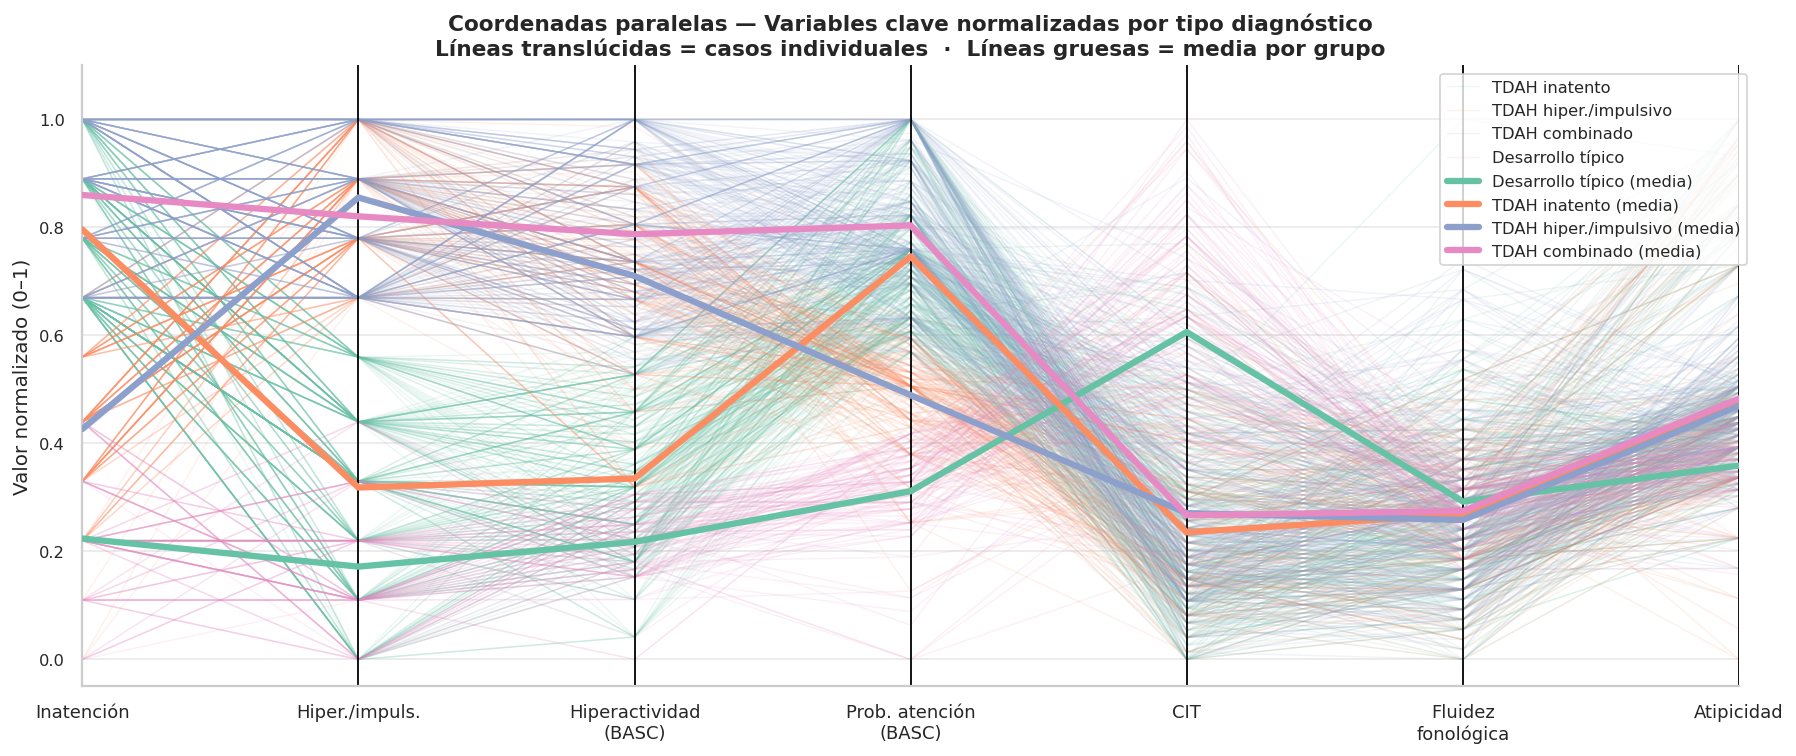

In [18]:
from pandas.plotting import parallel_coordinates

vars_pc = ['indice_inatencion', 'indice_impuls_hiperac',
           'hiperactividad_basc3', 'problemas_atencion_basc3',
           'cit', 'fluidez_fonologica', 'atipicidad_basc3']
labels_pc = ['Inatención', 'Hiper./impuls.',
             'Hiperactividad\n(BASC)', 'Prob. atención\n(BASC)',
             'CIT', 'Fluidez\nfonológica', 'Atipicidad']

df_pc = df[vars_pc + ['tipo_tdah']].copy()
for col in vars_pc:
    df_pc[col] = (df_pc[col] - df_pc[col].min()) / (df_pc[col].max() - df_pc[col].min())
df_pc.columns = labels_pc + ['tipo_tdah']

fig, ax = plt.subplots(figsize=(14, 6))
parallel_coordinates(df_pc, 'tipo_tdah', color=PAL4, alpha=0.12, linewidth=0.8, ax=ax)

medias_pc = df_pc.groupby('tipo_tdah')[labels_pc].mean().reindex(ORDEN4)
x_pos = range(len(labels_pc))
for i, tipo in enumerate(ORDEN4):
    ax.plot(x_pos, medias_pc.loc[tipo].values,
            color=PAL4[i], linewidth=3.5, label=f'{tipo} (media)', zorder=5)

ax.set_xticklabels(labels_pc, fontsize=10)
ax.set_ylabel('Valor normalizado (0–1)')
ax.set_title('Coordenadas paralelas — Variables clave normalizadas por tipo diagnóstico\nLíneas translúcidas = casos individuales  ·  Líneas gruesas = media por grupo',
             fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.01, 1), fontsize=9)
ax.grid(axis='y', alpha=0.4)
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()


📋 **Interpretación — Coordenadas paralelas**

**Cómo leerlo:** cada línea translúcida representa un paciente individual. El eje X son las variables (normalizadas 0–1) y el eje Y es el valor de ese paciente en esa variable. Las líneas gruesas son las medias de cada grupo, equivalentes a lo que muestra el radar chart pero con el contexto de la variabilidad individual.

**Qué aporta que el radar chart no muestra:**
- **Solapamiento entre grupos:** si las líneas de diferentes colores se mezclan mucho en una variable, esa variable no separa bien a los grupos en la práctica, aunque las medias sean distintas. Un Kruskal-Wallis puede ser significativo pero si el solapamiento es grande, la capacidad discriminativa real es limitada.
- **Variabilidad intra-grupo:** grupos con líneas muy dispersas tienen alta heterogeneidad interna — son diagnósticos que agrupan perfiles muy distintos entre sí.
- **Trayectorias individuales:** si muchas líneas del mismo color tienen trayectorias similares (suben o bajan juntas entre variables), indica que esas variables van juntas *dentro de ese grupo*.

**Qué buscar concretamente:**
- Las columnas de Inatención e Hiperactividad deberían mostrar una *inversión*: los grupos que son altos en una tienden a ser bajos en la otra, lo que visualmente se ve como líneas cruzadas entre esas dos columnas.
- *Desarrollo típico* (el primer color) debería concentrar sus líneas en la zona baja de Inatención, Hiperactividad y Problemas de atención, y relativamente más alta en CIT y Fluidez.
- La densidad de líneas en zonas extremas (cerca de 0 o cerca de 1) indica cuántos casos tienen valores muy bajos o muy altos en esa variable.

---

### Comparación de las tres visualizaciones

| Visualización | Fortaleza | Limitación |
|---|---|---|
| **Heatmap z-scores** | Máxima granularidad (13 grupos × 12 variables) | Requiere tiempo para leerlo; no muestra variabilidad |
| **Radar chart** | Intuitivo, fácil de comunicar, compara formas de perfil | Solo 4 grupos; no muestra datos individuales |
| **Coordenadas paralelas** | Muestra solapamiento y variabilidad real entre casos | Puede saturarse visualmente con muchos grupos/variables |


---
## Síntesis del análisis bivariado

In [19]:
vars_all_num = ['indice_tdah', 'indice_inatencion', 'indice_impuls_hiperac',
                'cit', 'fluidez_fonologica',
                'agresividad_basc3', 'hiperactividad_basc3', 'problemas_conducta_basc3',
                'problemas_atencion_basc3', 'atipicidad_basc3',
                'edad', 'escolaridad']
kw_global = test_kw(df, vars_all_num)
print("Ranking de variables por poder discriminante (H de Kruskal-Wallis, mayor = más discriminante)")
display(kw_global.sort_values('H (KW)', ascending=False))


Ranking de variables por poder discriminante (H de Kruskal-Wallis, mayor = más discriminante)


,H (KW),p-valor,Significativo (α=0.05)
Variable,,,
indice_impuls_hiperac,678.128,1.1602e-146,Sí
indice_tdah,652.834,3.5388e-141,Sí
hiperactividad_basc3,650.946,9.0825e-141,Sí
indice_inatencion,611.768,2.8332e-132,Sí
problemas_atencion_basc3,596.322,6.3205e-129,Sí
problemas_conducta_basc3,419.107,1.6075e-90,Sí
agresividad_basc3,286.036,1.0466e-61,Sí
cit,197.408,1.5320e-42,Sí
atipicidad_basc3,94.434,2.4436e-20,Sí


📋 **Interpretación — Ranking de poder discriminante**

La tabla ordena las variables de mayor a menor estadístico H. Este ranking indica cuáles variables distinguen mejor entre los 4 tipos diagnósticos principales.

**Cómo usar este ranking:**
- Las variables con **H alto y p significativo** son los mejores candidatos como *features* en un modelo de clasificación o como ejes de análisis en etapas posteriores.
- Las variables con **H bajo o p no significativo** son menos útiles para distinguir entre tipos — aunque pueden ser clínicamente relevantes en otros contextos (p.ej. para caracterizar la severidad dentro de un mismo subtipo).
- Este ranking no implica causalidad: una variable con H alto simplemente tiene distribuciones más diferentes entre grupos, no necesariamente es la "causa" del diagnóstico.

**Siguiente paso sugerido:** análisis de reducción de dimensionalidad (PCA o UMAP) para visualizar si los 4 tipos diagnósticos forman clusters separables en el espacio multivariado, usando las variables con mayor H como punto de partida.
